# 1. Plot tac vs Ure rec exemple (Exemple)

### - Tac rec

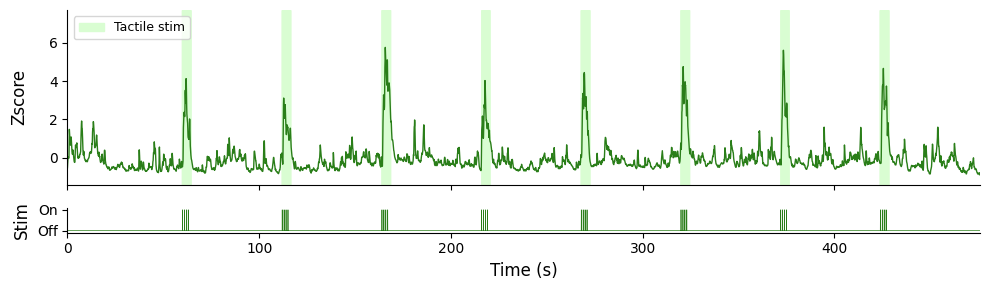

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os

# 1. Chargement des données
final_df = pd.read_excel(
    'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Tac_vs_Tac_ure/Df_Zscore_classic_tac.xlsx',
    sheet_name='Master_sheet'
)

# 2. Définir l'animal souhaité
animal_tac = '2023.10.06'  # Remplacez par l'animal souhaité

# 3. Filtrage des données pour l'animal spécifié
df_tac_filtered = final_df[final_df['animal'] == animal_tac].copy()

# 4. Conversion du temps en secondes
df_tac_filtered['time_sec'] = df_tac_filtered['time'] / 1000


# Création de la figure avec deux sous-graphes
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 3), sharex=True, gridspec_kw={'height_ratios': [7, 1]})

# 1er Subplot : Zscore
sns.lineplot(
    x='time_sec', y='Zscore', data=df_tac_filtered,
    ax=ax1, color='#2a7e19', linewidth=1, errorbar=None  # Suppression de l'ombre
) #ci=None

# Ajuster les labels et les limites du premier subplot
ax1.set_ylabel('Zscore', labelpad=15)
ax1.set_ylim(-1.4, 7.7)
ax1.set_xlim(0, 476)

# Couleur pour la période "TS"
thermic_color = '#d9fdd2'#d1ffdb'

# Périodes de stimulation thermiques
ts_periods_thermic = df_tac_filtered[df_tac_filtered['period'].str.startswith('TS_', na=False)].sort_values(by='time')
for _, row in ts_periods_thermic.iterrows():
    start_time_tac_raw = row['time'] / 1000
    end_time_tac_raw = (row['time'] + 2000) / 1000  # Durée de 2 secondes
    ax1.axvspan(start_time_tac_raw, end_time_tac_raw, color=thermic_color, zorder=0, label='Tactile stim')

# Suppression des duplicatas dans les légendes
handles, labels = ax1.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax1.legend(by_label.values(), by_label.keys(), loc='upper left')

# Définir les périodes de stimulation
stim_periods = {
    'TS_1': (60, 63),
    'TS_2': (112, 115),
    'TS_3': (164, 167),
    'TS_4': (216, 219),
    'TS_5': (268, 271),
    'TS_6': (320, 323),
    'TS_7': (372, 375),
    'TS_8': (424, 427)
}

# Générer une série temporelle pour tracer les pulses
time_series = np.linspace(0, df_tac_filtered['time_sec'].max(), int(df_tac_filtered['time_sec'].max() * 100))
pulse_series = np.zeros_like(time_series)

# Paramètres des pulses
pulse_width = 0.05  # Largeur d'un pulse (en secondes)
num_pulses = 4  # Nombre de pulses par stimulation

# Ajout des pulses en fonction des périodes
for period, (start, end) in stim_periods.items():
    pulse_times = np.linspace(start, end, num_pulses)
    for pulse_time in pulse_times:
        pulse_indices = np.where((time_series >= pulse_time) & (time_series < pulse_time + pulse_width))[0]
        pulse_series[pulse_indices] = 1

# 2e Subplot : Pulses carrés
ax2.plot(time_series, pulse_series, color='#2a7e19', linewidth=0.5)

# Ajuster les labels et l'échelle du deuxième subplot
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Stim')
ax2.set_yticks([0, 1])
ax2.set_ylim(-0.1, 1.1)
ax2.set_yticklabels(['Off', 'On'])

# Enlever les bordures inutiles
# Enlever les bordures inutiles
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# Ajuster l'espacement entre les sous-graphes
plt.subplots_adjust(hspace=0.06)

# Mise à jour des paramètres graphiques
plt.rcParams.update({
    'axes.titlesize': 12,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 9
})

plt.tight_layout()

# Sauvegarder la figure

# Afficher le graphique
plt.show()


### - Tac Ure rec

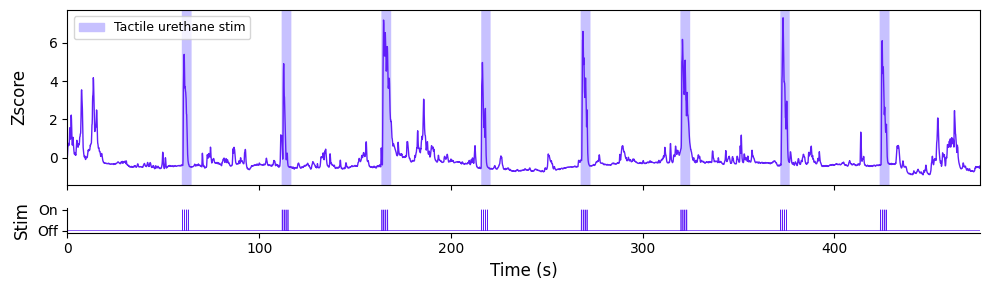

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os

# 1. Chargement des données
final_df = pd.read_excel('G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Tac_vs_Tac_ure/Df_Zscore_classic_tac_ure.xlsx', sheet_name='Master_sheet')

# 2. Définir l'animal et le rec souhaités
animal_tac = '2023.10.06'  # Remplacez par l'animal souhaité

# 3. Filtrage des données pour l'animal et le rec spécifiés
df_tac_filtered = final_df[(final_df['animal'] == animal_tac)].copy()

# 4. Conversion du temps en secondes pour les deux DataFrames
df_tac_filtered.loc[:, 'time_sec'] = df_tac_filtered['time'] / 1000

# Création de la figure avec deux sous-graphes
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 3), sharex=True, gridspec_kw={'height_ratios': [7, 1]})

# 1er Subplot : Zscore rec raw
sns.lineplot(x='time_sec', y='Zscore', data=df_tac_filtered, ax=ax1, color='#601ef9', linewidth=1, label=None) #914d65

# Ajuster les labels du premier subplot
ax1.set_ylabel('Zscore', labelpad=15)
ax1.set_ylim(-1.4, 7.7)
ax1.set_xlim(0, 476)

# Définir les périodes "TS" pour les deux DataFrames avec des couleurs transparentes
thermic_color = '#c7c1ff'  #'#e4cbff'  # Couleur pour la période thermic

# Périodes de stimulation thermiques
ts_periods_thermic = df_tac_filtered[df_tac_filtered['period'].str.startswith('TS_', na=False)].sort_values(by='time')
for i, row in ts_periods_thermic.iterrows():
    start_time_tac_raw = row['time'] / 1000
    end_time_tac_raw = (row['time'] + 2000) / 1000  # Conversion en secondes (3.9s)
    ax1.axvspan(start_time_tac_raw, end_time_tac_raw, color=thermic_color, zorder=0, label='Tactile urethane stim')

# Suppression des duplicatas dans les légendes
handles, labels = ax1.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax1.legend(by_label.values(), by_label.keys(), loc='upper left')

# Définir les périodes de stimulation
stim_periods = {
    'TS_1': (60, 63),
    'TS_2': (112, 115),
    'TS_3': (164, 167),
    'TS_4': (216, 219),
    'TS_5': (268, 271),
    'TS_6': (320, 323),
    'TS_7': (372, 375),
    'TS_8': (424, 427)
}


# Générer une série temporelle pour tracer les pulses
time_series = np.linspace(0, df_tac_filtered['time_sec'].max(), int(df_tac_filtered['time_sec'].max() * 100))  # Temps échantillonné à 10 ms
pulse_series = np.zeros_like(time_series)

# Paramètres des pulses
pulse_width = 0.05  # Largeur d'un pulse (en secondes) réduite
num_pulses = 4  # Nombre de pulses par stimulation

# Ajout des pulses en fonction des périodes thermiques
for period, (start, end) in stim_periods.items():
    # Calculer les positions des 5 barres (espacées uniformément)
    pulse_times = np.linspace(start, end, num_pulses)

    # Placer les pulses dans la série temporelle
    for pulse_time in pulse_times:
        pulse_indices = np.where((time_series >= pulse_time) & (time_series < pulse_time + pulse_width))[0]
        pulse_series[pulse_indices] = 1  # Définir la hauteur du pulse

# Deuxième Subplot : Pulses carrés
ax2.plot(time_series, pulse_series, color='#601ef9', linewidth=0.5)

# Ajuster les labels et l'échelle
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Stim')
ax2.set_yticks([0, 1])
ax2.set_ylim(-0.1, 1.1)  # Ajuster pour rendre les pulses visibles
ax2.set_yticklabels(['Off', 'On'])

# Enlever les bordures
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# Ajuster l'espacement entre les sous-graphes
plt.subplots_adjust(hspace=0.06)


plt.rcParams.update({
    'axes.titlesize': 12,   # Taille du titre des axes
    'axes.labelsize': 12,   # Taille des labels des axes
    'xtick.labelsize': 10,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 10,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 9   # Taille de la police de la légende
})


plt.tight_layout()


# Afficher le graphique
plt.show()


# 2. Plot PSTC

Valeur maximale de Znorm pour la condition Tactile (entre 0 et 2.1 s) : 4.574219835302187
Valeur maximale de Znorm pour la condition Tactile Urethane (entre 0 et 2.1 s) : 6.077755901068058


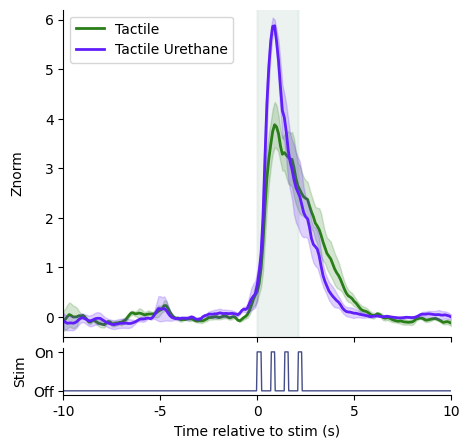

In [1]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
import numpy as np

# Répertoires contenant les fichiers Excel
input_directory_tac = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Tac_vs_Tac_ure/Df_tac_Trial_Mean_SEM/'
input_directory_ure = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Tac_vs_Tac_ure/Df_tac_ure_Trial_Mean_SEM/'

# Trouver tous les fichiers correspondant au modèle pour les deux datasets
file_pattern_tac = os.path.join(input_directory_tac, 'Df_Zscore_classic_tac_*_trial_mean_SEM.xlsx')
file_pattern_ure = os.path.join(input_directory_ure, 'Df_Zscore_classic_tac_ure_*_trial_mean_SEM.xlsx')

files_1 = glob.glob(file_pattern_tac)
files_2 = glob.glob(file_pattern_ure)

# Charger et combiner les données de tous les fichiers pour les deux datasets
dfs_1 = []
for file_path in files_1:
    df = pd.read_excel(file_path)
    file_name = os.path.basename(file_path)
    save_file_name = file_name.split('_', 2)[2].replace('.xlsx', '')
    df['FileName'] = save_file_name
    dfs_1.append(df)

dfs_2 = []
for file_path in files_2:
    df = pd.read_excel(file_path)
    file_name = os.path.basename(file_path)
    save_file_name = file_name.split('_', 2)[2].replace('.xlsx', '')
    df['FileName'] = save_file_name
    dfs_2.append(df)

# Combiner les deux datasets
df_combined_1 = pd.concat(dfs_1, ignore_index=True)
df_combined_2 = pd.concat(dfs_2, ignore_index=True)

# Ajouter une colonne 'time_sec' en convertissant 'Stim_Time' en secondes pour les deux datasets
df_combined_1['time_sec'] = df_combined_1['Stim_Time'] / 1000
df_combined_2['time_sec'] = df_combined_2['Stim_Time'] / 1000

# Création de la figure avec deux sous-graphes
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(5, 5), sharex=True, gridspec_kw={'height_ratios': [7, 1]})

# Calculer la moyenne et SEM pour le premier dataset
mean_zscore_1 = df_combined_1.groupby('time_sec')['Mean_Znorm'].mean().reset_index()
SEM_zscore_1 = df_combined_1.groupby('time_sec')['Mean_Znorm'].sem().reset_index()

# Calculer la moyenne et SEM pour le second dataset
mean_zscore_2 = df_combined_2.groupby('time_sec')['Mean_Znorm'].mean().reset_index()
SEM_zscore_2 = df_combined_2.groupby('time_sec')['Mean_Znorm'].sem().reset_index()

# Tracer la courbe moyenne et l'ombre de SEM pour le premier dataset
ax1.plot(mean_zscore_1['time_sec'], mean_zscore_1['Mean_Znorm'], color='#2a7e19', linewidth=2, linestyle='-', zorder=2, label='Tactile')
ax1.fill_between(mean_zscore_1['time_sec'], 
                 mean_zscore_1['Mean_Znorm'] - SEM_zscore_1['Mean_Znorm'], 
                 mean_zscore_1['Mean_Znorm'] + SEM_zscore_1['Mean_Znorm'], 
                 color='#2a7e19', alpha=0.2, zorder=2,) #5fa052

# Tracer la courbe moyenne et l'ombre de SEM pour le second dataset
ax1.plot(mean_zscore_2['time_sec'], mean_zscore_2['Mean_Znorm'], color='#601ef9', linewidth=2, linestyle='-', zorder=2, label='Tactile Urethane')
ax1.fill_between(mean_zscore_2['time_sec'], 
                 mean_zscore_2['Mean_Znorm'] - SEM_zscore_2['Mean_Znorm'], 
                 mean_zscore_2['Mean_Znorm'] + SEM_zscore_2['Mean_Znorm'], 
                 color='#601ef9', alpha=0.2, zorder=2)


# # Ajouter la période TS en arrière-plan cool stim
color_ts = '#e3efe9' 

in_ts_period = False
start_time = None
for i, row in df_combined_2.iterrows():
    if row['period'] == 'TS':
        if not in_ts_period:
            start_time = row['time_sec']
            in_ts_period = True
    elif in_ts_period:
        end_time = row['time_sec']
        ax1.fill_between(df_combined_2['time_sec'], -1, 10, 
                         where=(df_combined_2['time_sec'] >= start_time) & (df_combined_2['time_sec'] <= end_time),
                         color=color_ts, alpha=0.1, zorder=0.5)
        in_ts_period = False


# Ajouter la légende au premier subplot
ax1.legend(loc='upper left')

ax1.set_ylabel('Znorm', labelpad=15)
ax1.set_ylim(-0.4, 6.2)
ax1.set_xlim(-10, 10)

ax1.set_xticks([-10, -5, 0, 5, 10])
ax1.set_xticklabels(['-10', '-5', '0', '5', '10'])
ax1.set_xlim(-10, 10)


# Deuxième Subplot : Pulses carrés
# Initialiser la série temporelle pour les pulses
time_series = np.linspace(-10, 10, len(df_combined_1))  # Représentation de la série temporelle pour toute la période
pulse_series = np.zeros_like(time_series)

# Paramètres des pulses
pulse_width = 0.2  # Largeur d'un pulse (en secondes) réduite
num_pulses = 4  # Nombre de pulses par stimulation

# Ajouter les pulses dans la série temporelle, en prenant la période "TS" du premier subplot
in_ts_period = False
start_time = None
for i, row in df_combined_1.iterrows():
    if row['period'] == 'TS':
        if not in_ts_period:
            start_time = row['time_sec']
            in_ts_period = True
    elif in_ts_period:
        end_time = row['time_sec']
        
        # Remplir la zone pour la période TS dans le subplot 2 (ax2)
        pulse_times = np.linspace(start_time, end_time, num_pulses)
        for pulse_time in pulse_times:
            pulse_indices = np.where((time_series >= pulse_time) & (time_series < pulse_time + pulse_width))[0]
            pulse_series[pulse_indices] = 1  # Définir la hauteur du pulse
            
        in_ts_period = False

# Si la période TS se termine à la dernière ligne
if in_ts_period:
    end_time = df_combined_1['time_sec'].iloc[-1]
    pulse_times = np.linspace(start_time, end_time, num_pulses)
    for pulse_time in pulse_times:
        pulse_indices = np.where((time_series >= pulse_time) & (time_series < pulse_time + pulse_width))[0]
        pulse_series[pulse_indices] = 1  # Définir la hauteur du pulse

# Tracer les pulses sur le deuxième subplot
ax2.plot(time_series, pulse_series, color='#454e89', linewidth=1)#5fa052

# Ajuster les labels et l'échelle
ax2.set_xlabel('Time relative to stim (s)')
ax2.set_ylabel('Stim')
ax2.set_yticks([0, 1])
ax2.set_ylim(-0.1, 1.1)  # Ajuster pour rendre les pulses visibles
ax2.set_yticklabels(['Off', 'On'])


# Ajuster l'espacement entre les sous-graphes
plt.subplots_adjust(hspace=0.06)


# Ajouter les lignes pour trouver les valeurs maximales de Znorm entre 0 et 3.9 secondes
# Filtrer les données pour la condition Cool entre 0 et 3.9 secondes
condition_tac_filtered = df_combined_1[(df_combined_1['time_sec'] >= 0) & (df_combined_1['time_sec'] <= 2.1)]
max_zscore_tac = condition_tac_filtered['Mean_Znorm'].max()

# Filtrer les données pour la condition Cool Urethane entre 0 et 3.9 secondes
condition_tac_urethane_filtered = df_combined_2[(df_combined_2['time_sec'] >= 0) & (df_combined_2['time_sec'] <= 2.1)]
max_zscore_tac_urethane = condition_tac_urethane_filtered['Mean_Znorm'].max()

# Afficher les valeurs maximales
print(f"Valeur maximale de Znorm pour la condition Tactile (entre 0 et 2.1 s) : {max_zscore_tac}")
print(f"Valeur maximale de Znorm pour la condition Tactile Urethane (entre 0 et 2.1 s) : {max_zscore_tac_urethane}")


#Ajustement des bordures
# Enlever les bordures du haut et de droite pour le premier subplot (ax1)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Enlever les bordures du haut et de droite pour le deuxième subplot (ax2)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)


plt.rcParams.update({
    'axes.titlesize': 12,   # Taille du titre des axes
    'axes.labelsize': 10,   # Taille des labels des axes
    'xtick.labelsize': 10,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 10,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 9   # Taille de la police de la légende
})

plt.tight_layout

# Afficher le graphique
plt.show()


# 3. Ploting AUC for cool vs hot

### 3.1. N = animals

--- Statistiques pour la condition Tactile ---
TB:  -0.4107 ± 0.4090, n = 3
  Test de Shapiro-Wilk : Stat = 0.7669, p-value = 0.0377

TS:  18.7709 ± 2.8709, n = 3
  Test de Shapiro-Wilk : Stat = 0.8768, p-value = 0.3150

PTS:  0.5475 ± 1.2444, n = 3
  Test de Shapiro-Wilk : Stat = 0.8660, p-value = 0.2842

--- Statistiques pour la condition Tactile Urethane ---
TB:  0.1998 ± 0.0779, n = 3
  Test de Shapiro-Wilk : Stat = 0.7640, p-value = 0.0312

TS:  35.8213 ± 2.7136, n = 3
  Test de Shapiro-Wilk : Stat = 0.9748, p-value = 0.6958

PTS:  3.6593 ± 0.9369, n = 3
  Test de Shapiro-Wilk : Stat = 0.9995, p-value = 0.9589



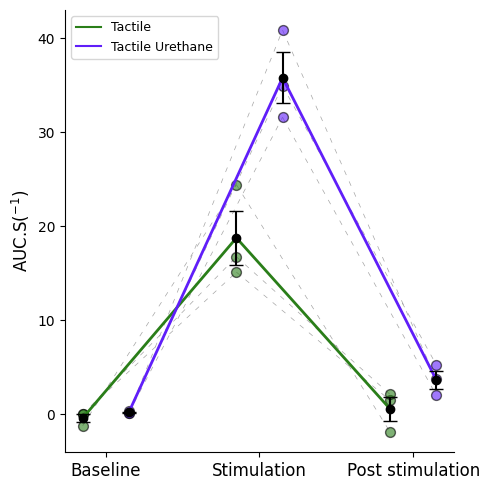

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import shapiro
from scipy.stats import friedmanchisquare, wilcoxon
from scikit_posthocs import posthoc_dunn
import os
import matplotlib.lines as mlines

# Chemins vers les fichiers Excel pour chaque variable
file_path_auc_tac = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Tac_vs_Tac_ure/Quantif_by_Periods/AUC_persec_Znorm_by_Period_animal_tac.xlsx'
file_path_auc_ure = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Tac_vs_Tac_ure/Quantif_by_Periods/AUC_persec_Znorm_by_Period_animal_tac_ure.xlsx'

# Charger les données
df_auc_tac = pd.read_excel(file_path_auc_tac)
df_auc_ure = pd.read_excel(file_path_auc_ure)

# Ajouter une colonne pour identifier la condition
df_auc_tac['Condition'] = 'Tactile'
df_auc_ure['Condition'] = 'Tactile Urethane'

# Fusionner les deux datasets en un seul pour simplifier la gestion
df_combined = pd.concat([df_auc_tac, df_auc_ure], ignore_index=True)

# Définir les périodes
periods = ['TB', 'TS', 'PTS']

# Filtrer les données par période pour chaque variable
df_periods = {
    'Tactile': {period: df_combined[(df_combined['Period'] == period) & (df_combined['Condition'] == 'Tactile')] for period in periods},
    'Tactile Urethane': {period: df_combined[(df_combined['Period'] == period) & (df_combined['Condition'] == 'Tactile Urethane')] for period in periods},
}

# Fonction pour calculer les moyennes, SEM, et Shapiro pour chaque condition et période
def calculate_stats(df_periods, condition_name, variable_name):
    stats = {}
    for period in periods:
        data = df_periods[condition_name][period][variable_name].dropna()
        n = len(data)
        mean_value = data.mean()
        sem_value = data.sem()
        shapiro_stat, shapiro_p = shapiro(data)
        stats[period] = {
            'mean': mean_value,
            'sem': sem_value,
            'n': n,
            'shapiro_stat': shapiro_stat,
            'shapiro_p': shapiro_p
        }
    return stats

# Calculer les statistiques pour les deux conditions
stats_tactile = calculate_stats(df_periods, 'Tactile', 'AUC_Znorm_persec')
stats_ure = calculate_stats(df_periods, 'Tactile Urethane', 'AUC_Znorm_persec')

# Afficher les résultats pour chaque condition et période
def print_stats(stats, condition_name):
    print(f"--- Statistiques pour la condition {condition_name} ---")
    for period in periods:
        mean = stats[period]['mean']
        sem = stats[period]['sem']
        n = stats[period]['n']
        shapiro_stat = stats[period]['shapiro_stat']
        shapiro_p = stats[period]['shapiro_p']
        print(f"{period}:  {mean:.4f} ± {sem:.4f}, n = {n}")
        print(f"  Test de Shapiro-Wilk : Stat = {shapiro_stat:.4f}, p-value = {shapiro_p:.4f}")
        print("")

# Afficher les statistiques pour chaque condition
print_stats(stats_tactile, 'Tactile')
print_stats(stats_ure, 'Tactile Urethane')

# Préparer les positions décalées et les couleurs
positions = {'TB': 1, 'TS': 2, 'PTS': 3}
offsets = {'AUC_Znorm_persec_Tactile': -0.15, 'AUC_Znorm_persec_ure': 0.15}
colors = {
    'AUC_Znorm_persec_Tactile': '#2a7e19',
    'AUC_Znorm_persec_ure': '#601ef9'
}
border_colors = {key: 'black' for key in colors}


# Fonction pour tracer les points, les moyennes et les écarts-types pour chaque variable
def plot_variable(df_periods, condition_name, variable_name, color, border_color, offset):
    means = {period: df_periods[condition_name][period][variable_name].mean() for period in periods}
    sems = {period: df_periods[condition_name][period][variable_name].sem() for period in periods}
    for period in periods:
        y_values = df_periods[condition_name][period][variable_name].values
        x_values = [positions[period] + offset] * len(y_values)
        plt.scatter(x_values, y_values, color=color, edgecolor=border_color, linewidth=1, alpha=0.6, marker='o', s=50, zorder=1)
        mean_value = means[period]
        sem_value = sems[period]
        plt.errorbar(positions[period] + offset, mean_value, yerr=sem_value, fmt='o', color='black', capsize=5, zorder=2)
    return means, sems

# Tracer les données pour chaque variable
plt.figure(figsize=(5, 5))
means_Tactile, sems_Tactile = plot_variable(df_periods, 'Tactile', 'AUC_Znorm_persec', colors['AUC_Znorm_persec_Tactile'], border_colors['AUC_Znorm_persec_Tactile'], offsets['AUC_Znorm_persec_Tactile'])
means_ure, sems_ure = plot_variable(df_periods, 'Tactile Urethane', 'AUC_Znorm_persec', colors['AUC_Znorm_persec_ure'], border_colors['AUC_Znorm_persec_ure'], offsets['AUC_Znorm_persec_ure'])


# Créer des objets Line2D pour la légende avec les couleurs souhaitées
legend_line_tactile = mlines.Line2D([], [], color=colors['AUC_Znorm_persec_Tactile'], label='Tactile')
legend_line_ure = mlines.Line2D([], [], color=colors['AUC_Znorm_persec_ure'], label='Tactile Urethane')

# Ajouter la légende avec les couleurs personnalisées
plt.legend(handles=[legend_line_tactile, legend_line_ure], loc='upper left')


# Ajouter des connexions entre les périodes
def plot_connections(means, variable_name, color, offset):
    for i in range(len(periods) - 1):
        x1, x2 = positions[periods[i]] + offset, positions[periods[i + 1]] + offset
        y1, y2 = means[periods[i]], means[periods[i + 1]]
        plt.plot([x1, x2], [y1, y2], color=color, linestyle='-', linewidth=2, zorder=1)

plot_connections(means_Tactile, 'AUC_Znorm_persec_Tactile', colors['AUC_Znorm_persec_Tactile'], offsets['AUC_Znorm_persec_Tactile'])
plot_connections(means_ure, 'AUC_Znorm_persec_ure', colors['AUC_Znorm_persec_ure'], offsets['AUC_Znorm_persec_ure'])


# Ajouter des lignes reliant chaque point pour un même animal et condition
def plot_connections_per_animal(df_combined, condition_name, variable_name, offset, color):
    # Filtrer par condition et par animal
    for animal in df_combined[df_combined['Condition'] == condition_name]['Animal'].unique():
        animal_data = df_combined[(df_combined['Condition'] == condition_name) & (df_combined['Animal'] == animal)]
        
        # Relier les points pour chaque période pour cet animal
        for i, period in enumerate(periods[:-1]):
            x1 = positions[period] + offset
            x2 = positions[periods[i + 1]] + offset
            y1 = animal_data[animal_data['Period'] == period][variable_name].values[0]
            y2 = animal_data[animal_data['Period'] == periods[i + 1]][variable_name].values[0]
            
            # Tracer une ligne entre les points
            plt.plot([x1, x2], [y1, y2], color='grey', linestyle='--', dashes=(7, 10), linewidth=0.5, alpha=0.7, zorder=0)

plot_connections_per_animal(df_combined, 'Tactile', 'AUC_Znorm_persec', offsets['AUC_Znorm_persec_Tactile'], colors['AUC_Znorm_persec_Tactile'])
plot_connections_per_animal(df_combined, 'Tactile Urethane', 'AUC_Znorm_persec', offsets['AUC_Znorm_persec_ure'], colors['AUC_Znorm_persec_ure'])


# Enlever les bordures du haut et de droite pour le premier subplot (ax1)
ax = plt.gca()  # Obtenir les axes actuels
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Réglages finaux
plt.xticks([positions[period] for period in periods], ['Baseline', 'Stimulation', 'Post stimulation'])
plt.ylabel(r'AUC.S($^{-1}$)')
# plt.grid(axis='y')


plt.rcParams.update({
    'axes.titlesize': 12,   # Taille du titre des axes
    'axes.labelsize': 12,   # Taille des labels des axes
    'xtick.labelsize': 12,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 10,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 9   # Taille de la police de la légende
})

plt.tight_layout()


plt.show()


# N = trials

--- Statistiques pour la condition Tactile ---
TB:  -0.4107 ± 0.5268, n = 24
  Test de Shapiro-Wilk : Stat = 0.9033, p-value = 0.0253

TS:  18.7709 ± 1.6637, n = 24
  Test de Shapiro-Wilk : Stat = 0.9095, p-value = 0.0344

PTS:  0.5475 ± 0.7262, n = 24
  Test de Shapiro-Wilk : Stat = 0.9677, p-value = 0.6118

--- Statistiques pour la condition Ure ---
TB:  0.1998 ± 0.0817, n = 24
  Test de Shapiro-Wilk : Stat = 0.6278, p-value = 0.0000

TS:  35.8213 ± 1.4274, n = 24
  Test de Shapiro-Wilk : Stat = 0.9404, p-value = 0.1662

PTS:  3.6593 ± 0.9727, n = 24
  Test de Shapiro-Wilk : Stat = 0.8979, p-value = 0.0194



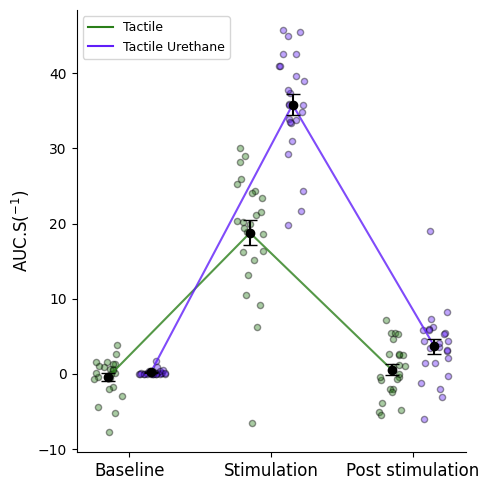

In [4]:
import matplotlib.pyplot as plt 
import pandas as pd
import numpy as np
from scipy.stats import shapiro
from scikit_posthocs import posthoc_dunn
import matplotlib.lines as mlines


# Chemins vers les fichiers Excel pour chaque variable
file_path_auc_tac = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Tac_vs_Tac_ure/Quantif_by_Periods/AUC_persec_Znorm_by_Period_tac.xlsx'
file_path_auc_ure = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Tac_vs_Tac_ure/Quantif_by_Periods/AUC_persec_Znorm_by_Period_tac_ure.xlsx'

# Charger les données
df_auc_tac = pd.read_excel(file_path_auc_tac)
df_auc_ure = pd.read_excel(file_path_auc_ure)

# Ajouter une colonne pour identifier la condition
df_auc_tac['Condition'] = 'Tac'
df_auc_ure['Condition'] = 'Ure'

# Extraire le type de période (TB, TS, PTS)
df_auc_tac['Period_type'] = df_auc_tac['Period'].str.extract(r'([A-Za-z]+)')
df_auc_ure['Period_type'] = df_auc_ure['Period'].str.extract(r'([A-Za-z]+)')

# Fusionner les deux datasets en un seul pour simplifier la gestion
df_combined = pd.concat([df_auc_tac, df_auc_ure], ignore_index=True)

# Définir les périodes
Periods = ['TB', 'TS', 'PTS']


# Filtrer les données par période pour chaque variable
df_Periods = {
    'Tactile': {Period: df_combined[(df_combined['Period_type'] == Period) & (df_combined['Condition'] == 'Tac')] for Period in Periods},
    'Ure': {Period: df_combined[(df_combined['Period_type'] == Period) & (df_combined['Condition'] == 'Ure')] for Period in Periods},
}

# Préparer les positions décalées et les couleurs
positions = {'TB': 1, 'TS': 2, 'PTS': 3}
offsets = {'AUC_Znorm_persec_Tac': -0.15, 'AUC_Znorm_persec_ure': 0.15}
colors = {
    'AUC_Znorm_persec_Tac': '#2a7e19',
    'AUC_Znorm_persec_ure': '#601ef9'
}
border_colors = {key: 'black' for key in colors}

# Fonction pour ajouter du jitter aux données
def add_jitter(x_values, jitter_strength=0.1):
    return x_values + np.random.uniform(-jitter_strength, jitter_strength, size=len(x_values))

# Fonction pour calculer les statistiques de chaque période
def calculate_stats(df_Periods, condition_name, variable_name):
    stats = {}
    for Period in Periods:
        data = df_Periods[condition_name][Period][variable_name]
        mean = data.mean()
        sem = data.sem()
        n = len(data)
        # Test de normalité de Shapiro-Wilk

        shapiro_stat, shapiro_p = shapiro(data)
        stats[Period] = {
            'mean': mean,
            'sem': sem,
            'n': n,
            'shapiro_stat': shapiro_stat,
            'shapiro_p': shapiro_p
        }
    return stats

# Fonction pour afficher les statistiques de manière lisible
def print_stats(stats, condition_name):
    print(f"--- Statistiques pour la condition {condition_name} ---")
    for period in Periods:
        mean = stats[period]['mean']
        sem = stats[period]['sem']
        n = stats[period]['n']
        shapiro_stat = stats[period]['shapiro_stat']
        shapiro_p = stats[period]['shapiro_p']
        print(f"{period}:  {mean:.4f} ± {sem:.4f}, n = {n}")
        print(f"  Test de Shapiro-Wilk : Stat = {shapiro_stat:.4f}, p-value = {shapiro_p:.4f}")
        print("")

# Calculer et afficher les statistiques pour chaque condition
stats_Tactile = calculate_stats(df_Periods, 'Tactile', 'AUC_Znorm_persec')
print_stats(stats_Tactile, 'Tactile')

stats_Ure = calculate_stats(df_Periods, 'Ure', 'AUC_Znorm_persec')
print_stats(stats_Ure, 'Ure')

# Fonction pour tracer les points, les moyennes et les écarts-types pour chaque variable
def plot_variable(df_Periods, condition_name, variable_name, color, border_color, offset):
    means = {Period: df_Periods[condition_name][Period][variable_name].mean() for Period in Periods}
    sems = {Period: df_Periods[condition_name][Period][variable_name].sem() for Period in Periods}
    for Period in Periods:
        y_values = df_Periods[condition_name][Period][variable_name].values
        x_values = [positions[Period] + offset] * len(y_values)
        
        # Ajouter du jitter aux positions des points
        x_values_jittered = add_jitter(x_values)
        
        plt.scatter(x_values_jittered, y_values, color=color, edgecolor=border_color, linewidth=1, alpha=0.4, marker='o', s=20, zorder=1)
        mean_value = means[Period]
        sem_value = sems[Period]
        plt.errorbar(positions[Period] + offset, mean_value, yerr=sem_value, fmt='o', color='black', capsize=5, zorder=2)
    return means, sems

# Tracer les données pour chaque variable
plt.figure(figsize=(5, 5))
means_Tactile, sems_Tactile = plot_variable(df_Periods, 'Tactile', 'AUC_Znorm_persec', colors['AUC_Znorm_persec_Tac'], border_colors['AUC_Znorm_persec_Tac'], offsets['AUC_Znorm_persec_Tac'])
means_ure, sems_ure = plot_variable(df_Periods, 'Ure', 'AUC_Znorm_persec', colors['AUC_Znorm_persec_ure'], border_colors['AUC_Znorm_persec_ure'], offsets['AUC_Znorm_persec_ure'])

# Créer des objets Line2D pour la légende avec les couleurs souhaitées
legend_line_tactile = mlines.Line2D([], [], color=colors['AUC_Znorm_persec_Tac'], label='Tactile')
legend_line_ure = mlines.Line2D([], [], color=colors['AUC_Znorm_persec_ure'], label='Tactile Urethane')

# Ajouter la légende avec les couleurs personnalisées
plt.legend(handles=[legend_line_tactile, legend_line_ure], loc='upper left')

# Ajouter des connexions entre les périodes
def plot_connections(means, variable_name, color, offset):
    for i in range(len(Periods) - 1):
        x1, x2 = positions[Periods[i]] + offset, positions[Periods[i + 1]] + offset
        y1, y2 = means[Periods[i]], means[Periods[i + 1]]
        plt.plot([x1, x2], [y1, y2], color=color, linestyle='-', linewidth=1.5, alpha=0.8, zorder=1)

plot_connections(means_Tactile, 'AUC_Znorm_persec_Tac', colors['AUC_Znorm_persec_Tac'], offsets['AUC_Znorm_persec_Tac'])
plot_connections(means_ure, 'AUC_Znorm_persec_ure', colors['AUC_Znorm_persec_ure'], offsets['AUC_Znorm_persec_ure'])

# Barplot des taux de réponse moyens par période avec sem
bar_width = 0.35

plt.xticks([positions[Period] for Period in Periods], ['Baseline', 'Stimulation', 'Post stimulation'])
plt.ylabel(r'AUC.S($^{-1}$)')

# Enlever les bordures du haut et de droite pour le premier subplot (ax1)
ax = plt.gca()  # Obtenir les axes actuels
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.rcParams.update({
    'axes.titlesize': 12,   # Taille du titre des axes
    'axes.labelsize': 12,   # Taille des labels des axes
    'xtick.labelsize': 12,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 10,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 9   # Taille de la police de la légende
})

plt.tight_layout()

# Affichage des statistiques de manière détaillée
plt.show()


#### Fichier merged Tactile-urethane AUC.s-1 for R stat

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import friedmanchisquare, wilcoxon
from scikit_posthocs import posthoc_dunn
import matplotlib.lines as mlines


# Chemins vers les fichiers Excel pour chaque variable
file_path_auc_tac = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Tac_vs_Tac_ure/Quantif_by_Periods/AUC_persec_Znorm_by_Period_tac.xlsx'
file_path_auc_ure = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Tac_vs_Tac_ure/Quantif_by_Periods/AUC_persec_Znorm_by_Period_tac_ure.xlsx'

# Charger les données
df_auc_tac = pd.read_excel(file_path_auc_tac)
df_auc_ure = pd.read_excel(file_path_auc_ure)

# Ajouter une colonne pour identifier la condition
df_auc_tac['Condition'] = 'Tac'
df_auc_ure['Condition'] = 'Ure'

# Extraire le type de période (TB, TS, PTS)
df_auc_tac['Period_type'] = df_auc_tac['Period'].str.extract(r'([A-Za-z]+)')
df_auc_ure['Period_type'] = df_auc_ure['Period'].str.extract(r'([A-Za-z]+)')

# Fusionner les deux datasets en un seul pour simplifier la gestion
df_combined = pd.concat([df_auc_tac, df_auc_ure], ignore_index=True)

# Définir les périodes
Periods = ['TB', 'TS', 'PTS']


# Filtrer les données par période pour chaque variable
df_Periods = {
    'Tactile': {Period: df_combined[(df_combined['Period_type'] == Period) & (df_combined['Condition'] == 'Tac')] for Period in Periods},
    'Ure': {Period: df_combined[(df_combined['Period_type'] == Period) & (df_combined['Condition'] == 'Ure')] for Period in Periods},
}

# Chemin pour le fichier Excel de sortie
output_file = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Tac_vs_Tac_ure/Quantif_by_Periods/AUC_persec_Znorm_Combined_tac_ure.xlsx'

# Sauvegarder le DataFrame dans un fichier Excel
df_combined.to_excel(output_file, index=False)

print(f"Le DataFrame df_combined a été sauvegardé dans le fichier : {output_file}")


Le DataFrame df_combined a été sauvegardé dans le fichier : G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Tac_vs_Tac_ure/Quantif_by_Periods/AUC_persec_Znorm_Combined_tac_ure.xlsx


# 4. Response rate by condition

### 4.1. with N = animals

In [1]:
import os
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Chemins des fichiers Excel
file_path_tac = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Tac_vs_Tac_ure/Thresholding_Tac_vs_Ure/Tac_responsive_rate.xlsx'
file_path_Ure = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Tac_vs_Tac_ure/Thresholding_Tac_vs_Ure/Tac_ure_responsive_rate.xlsx'

# Lecture des fichiers Excel
df_tac = pd.read_excel(file_path_tac)
df_Ure = pd.read_excel(file_path_Ure)

# Calcul du taux de réponse moyen par animal pour chaque condition
response_data_tac = df_tac.groupby(['animal', 'trial'])['response_rate'].mean().reset_index()
response_data_tac['response_rate'] *= 100  # En pourcentage

response_data_Ure = df_Ure.groupby(['animal', 'trial'])['response_rate'].mean().reset_index()
response_data_Ure['response_rate'] *= 100  # En pourcentage

# Ajout de la colonne 'condition' pour différencier les groupes
response_data_tac['condition'] = 'Tac'
response_data_Ure['condition'] = 'Ure'

# Combiner les données des deux conditions
combined_data = pd.concat([response_data_tac, response_data_Ure])

# Calculer la moyenne du taux de réponse par animal pour chaque condition
mean_response_per_animal = combined_data.groupby(['animal', 'condition'])['response_rate'].mean().reset_index()

# Calcul des moyennes et SEM pour chaque condition
mean_response_data = mean_response_per_animal.groupby('condition').agg(
    mean_response=('response_rate', 'mean'),
    sem_response=('response_rate', stats.sem)
).reset_index()

# Afficher la moyenne +/- SEM pour chaque condition
for condition in mean_response_data['condition']:
    mean_value = mean_response_data.loc[mean_response_data['condition'] == condition, 'mean_response'].values[0]
    sem_value = mean_response_data.loc[mean_response_data['condition'] == condition, 'sem_response'].values[0]
    print(f"{condition} condition: Mean = {mean_value:.2f} ± SEM = {sem_value:.2f}")

# Vérifier la normalité (Shapiro-Wilk) pour chaque condition
mean_response_tac = mean_response_per_animal[mean_response_per_animal['condition'] == 'Tac']['response_rate']
mean_response_Ure = mean_response_per_animal[mean_response_per_animal['condition'] == 'Ure']['response_rate']

normality_results = {
    "Tactile": stats.shapiro(mean_response_tac),
    "Urethane": stats.shapiro(mean_response_Ure)
}

print("\nRésultats des tests de normalité (Shapiro-Wilk) :")
for condition, result in normality_results.items():
    print(f"{condition}: Statistique = {result[0]:.4f}, p-value = {result[1]:.4f}")


    # Test de Wilcoxon (normalité non respectée)
    print("\nLes données ne sont pas normalement distribuées. On procède au test de Wilcoxon.")
    wilcoxon_results = stats.wilcoxon(mean_response_tac, mean_response_Ure)
    print("\nRésultats du test de Wilcoxon :")
    print(f"Statistique : {wilcoxon_results.statistic:.4f}")
    print(f"p-value : {wilcoxon_results.pvalue:.4f}")
    p_value = wilcoxon_results.pvalue

# Tracer les résultats
plt.figure(figsize=(2.5, 5))

# Barplot des taux de réponse moyens par condition avec SEM
bar_width = 0.75  # Réduire la largeur des barres
x = range(len(mean_response_data['condition']))

# Barres pour chaque condition
colors = ['#2a7e19', '#601ef9']  # Tactile (vert) et Ure (violet)
for i, condition in enumerate(mean_response_data['condition']):
    plt.bar(
        x[i],
        mean_response_data.loc[mean_response_data['condition'] == condition, 'mean_response'].values[0],
        width=bar_width,
        yerr=mean_response_data.loc[mean_response_data['condition'] == condition, 'sem_response'].values[0],
        label=f'{condition} Stim', color=colors[i], alpha=0.5, capsize=7)

# Ajouter des points individuels pour chaque condition avec jitter
jitter = 0.1
for i, (condition, color) in enumerate(zip(['Tac', 'Ure'], colors)):
    individual_data = mean_response_per_animal[mean_response_per_animal['condition'] == condition]
    jittered_x = [x[i] + np.random.uniform(-jitter, jitter) for _ in range(len(individual_data))]
    plt.scatter(
        jittered_x,
        individual_data['response_rate'],
        color=color,
        alpha=0.7,
        edgecolor='black',
        s=40  # Taille des points
    )

# Ajouter des barres de significativité
def add_significance_bar(x1, x2, y, p_val, height_offset=1):
    significance = ""
    if p_val < 0.001:
        significance = "***"
    elif p_val < 0.01:
        significance = "**"
    elif p_val < 0.05:
        significance = "*"

    if significance:
        plt.plot([x1, x1, x2, x2], [y, y + height_offset, y + height_offset, y], lw=1.5, color='black')
        plt.text((x1 + x2) * 0.5, y + height_offset + 0.5, significance, ha='center', va='bottom', color='black')

# Calculer les positions pour les barres de significativité
significance_y_position = max(mean_response_data['mean_response']) + 10  # Ajuster la position pour la significativité
add_significance_bar(x[0], x[1], significance_y_position, p_value)

# Mise en forme du graphique
plt.ylabel("Response rate (%)")
plt.xticks(x, mean_response_data['condition'])
plt.ylim(0, 110)

# Enlever les bordures du haut et de droite
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Paramètres de style
plt.rcParams.update({
    'axes.titlesize': 12,
    'axes.labelsize': 12,
    'xtick.labelsize': 12,
    'ytick.labelsize': 10,
    'legend.fontsize': 9
})

# Affichage du graphique
plt.tight_layout()


plt.show()


Tac condition: Mean = 100.00 ± SEM = 0.00
Ure condition: Mean = 100.00 ± SEM = 0.00

Résultats des tests de normalité (Shapiro-Wilk) :
Tactile: Statistique = 1.0000, p-value = 1.0000

Les données ne sont pas normalement distribuées. On procède au test de Wilcoxon.


c:\Users\zayan\Anaconda\envs\calcium1p\Lib\site-packages\scipy\stats\_axis_nan_policy.py:573: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  res = hypotest_fun_out(*samples, **kwds)


ValueError: zero_method 'wilcox' and 'pratt' do not work if x - y is zero for all elements.

### 4.2. with N = Trials (contengency)

In [ ]:
# import pandas as pd
# import matplotlib.pyplot as plt
# from statsmodels.stats.contingency_tables import mcnemar

# # Chargement des données (déjà fait dans ton code précédent)
# file_path_cool = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Tac_vs_Tac_ure/Thresholding_Thq_vs_Ure/Thq_responsive_rate.xlsx'
# file_path_Ure = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Tac_vs_Tac_ure/Thresholding_Thq_vs_Ure/Thq_ure_responsive_rate.xlsx'

# df_cool = pd.read_excel(file_path_cool)
# df_Ure = pd.read_excel(file_path_Ure)

# # Ajout de la colonne 'condition' pour différencier les groupes
# df_cool['condition'] = 'Cool'
# df_Ure['condition'] = 'Ure'

# # Combiner les données des deux conditions
# combined_data = pd.concat([df_cool, df_Ure])

# # Comptage des réponses (0 ou 1) par condition
# response_counts = combined_data.groupby(['condition', 'response_rate']).size().unsurek(fill_value=0)

# # Calcul des pourcentages de réponses 0 et 1 pour chaque condition
# response_percentages = response_counts.div(response_counts.sum(axis=1), axis=0) * 100

# # Création d'une table de contingence pour McNemar
# # Comparaison des réponses 0 et 1 pour Cool et Ure
# contingency_table = pd.crosstab(combined_data['response_rate'][combined_data['condition'] == 'Cool'],
#                                 combined_data['response_rate'][combined_data['condition'] == 'Ure'],
#                                 rownames=['Cool'], colnames=['Ure'])

# # Test de McNemar
# result = mcnemar(contingency_table, exact=True)

# # Affichage des résultats du test de McNemar
# print("Table de contingence :")
# print(contingency_table)
# print("\nRésultat du test de McNemar :")
# print(f"Statistique : {result.statistic}, p-value : {result.pvalue}")

# # Vérification de la significativité
# if result.pvalue < 0.001:
#     significance = "***"
# elif result.pvalue < 0.01:
#     significance = "**"
# elif result.pvalue < 0.05:
#     significance = "*"
# else:
#     significance = "ns"  # Pas significatif

# # Création du graphique (bar chart avec les pourcentages)
# fig, ax = plt.subplots(figsize=(2.5, 5))

# # Tracer la partie des barres correspondant à la réponse 1 (en couleur pleine et alpha = 0.5) pour Cool
# ax.bar('Cool', response_percentages.loc['Cool', 1], color='#2a7e19', alpha=0.5, label='Réponse 1 (Cool)', width=0.75)

# # Tracer la partie des barres correspondant à la réponse 0 (en couleur transparente et alpha = 0.1) pour Cool
# ax.bar('Cool', response_percentages.loc['Cool', 0], color='#2a7e19', alpha=0.1, label='Réponse 0 (Cool)', width=0.75, bottom=response_percentages.loc['Cool', 1])

# # Tracer la partie des barres correspondant à la réponse 1 (en couleur pleine et alpha = 0.5) pour Ure
# ax.bar('Ure', response_percentages.loc['Ure', 1], color='#601ef9', alpha=0.5, label='Réponse 1 (Ure)', width=0.75)

# # Tracer la partie des barres correspondant à la réponse 0 (en couleur transparente et alpha = 0.1) pour Ure
# ax.bar('Ure', response_percentages.loc['Ure', 0], color='#601ef9', alpha=0.1, label='Réponse 0 (Ure)', width=0.75, bottom=response_percentages.loc['Ure', 1])

# # # Ajouter une barre de significativité si la différence est significative
# # if result.pvalue < 0.05:
# #     # Ajouter la barre de significativité
# #     ax.plot([0, 1], [max(response_percentages.loc['Cool', 1], response_percentages.loc['Ure', 1]) + 10, 
# #                      max(response_percentages.loc['Cool', 1], response_percentages.loc['Ure', 1]) + 10],
# #             color='black', lw=1)

# # Ajouter une barre de significativité si la différence est significative
# if result.pvalue < 0.05:
#     # Calculer la position de la barre
#     y_bar = max(response_percentages.loc['Cool', 1], response_percentages.loc['Ure', 1]) + 10  # Position verticale

#     # Tracer la barre horizontale
#     ax.plot([0, 1], [y_bar, y_bar], color='black', lw=1)

#     # Ajouter de petites barres verticales aux extrémités
#     cap_height = 1  # Hauteur des petites barres
#     ax.plot([0, 0], [y_bar - cap_height, y_bar], color='black', lw=1)  # Cap à gauche
#     ax.plot([1, 1], [y_bar - cap_height, y_bar], color='black', lw=1)  # Cap à droite


#     # Ajouter les étoiles pour indiquer la significativité
#     ax.text(0.5, max(response_percentages.loc['Cool', 1], response_percentages.loc['Ure', 1]) + 10,
#             significance, ha='center', color='black')

# # Personnalisation du graphique
# # ax.set_title('Response rate for cool vs Ure condition')
# ax.set_ylabel('Response rate (%)')
# ax.set_xlabel('')
# ax.set_xticks(['Cool', 'Ure'])
# ax.set_xticklabels(['Cool', 'Ure'])

# ax = plt.gca()  # Obtenir les axes actuels
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)


# plt.rcParams.update({
#     'axes.titlesize': 12,   # Taille du titre des axes
#     'axes.labelsize': 12,   # Taille des labels des axes
#     'xtick.labelsize': 12,  # Taille des labels des ticks sur l'axe x
#     'ytick.labelsize': 10,  # Taille des labels des ticks sur l'axe y
#     'legend.fontsize': 9   # Taille de la police de la légende
# })

# # Affichage du graphique
# fig.tight_layout()

# # Sauvegarder la figure
# plt.savefig(os.path.join(saving_dir, 'Response_rate_thq_vs_ure_contengency.png'), format='png', dpi=300)
# plt.savefig(os.path.join(saving_dir, 'Response_rate_thq_vs_ure_contengency.svg'), format='svg', dpi=300)

# plt.show()


### 4.3 with N = Trials

In [ ]:
# import os
# import pandas as pd
# import scipy.stats as stats
# import matplotlib.pyplot as plt
# import numpy as np 

# # Chemins des fichiers Excel
# file_path_cool = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Tac_vs_Tac_ure/Thresholding_Thq_vs_Ure/Thq_responsive_rate.xlsx'
# file_path_Ure = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Tac_vs_Tac_ure/Thresholding_Thq_vs_Ure/Thq_ure_responsive_rate.xlsx'

# # Lecture des fichiers Excel
# df_cool = pd.read_excel(file_path_cool)
# df_Ure = pd.read_excel(file_path_Ure)

# # Calcul du taux de réponse moyen par trial pour chaque condition
# response_data_cool = df_cool.groupby(['animal', 'rec', 'trial'])['response_rate'].mean().reset_index()
# response_data_cool['response_rate'] *= 100  # En pourcentage

# response_data_Ure = df_Ure.groupby(['animal', 'rec', 'trial'])['response_rate'].mean().reset_index()
# response_data_Ure['response_rate'] *= 100  # En pourcentage

# # Ajout de la colonne 'condition' pour différencier les groupes
# response_data_cool['condition'] = 'Cool'
# response_data_Ure['condition'] = 'Ure'

# # Combiner les données des deux conditions
# combined_data = pd.concat([response_data_cool, response_data_Ure])

# # Vérifier la normalité (Shapiro-Wilk) pour chaque condition
# mean_response_cool = response_data_cool['response_rate']
# mean_response_Ure = response_data_Ure['response_rate']

# normality_results = {
#     "Cool": stats.shapiro(mean_response_cool),
#     "Ure": stats.shapiro(mean_response_Ure)
# }

# print("\nRésultats des tests de normalité (Shapiro-Wilk) :")
# for condition, result in normality_results.items():
#     print(f"{condition}: Statistique = {result[0]:.4f}, p-value = {result[1]:.4f}")

# # Choisir le test approprié en fonction des résultats de normalité
# if all(result[1] > 0.05 for result in normality_results.values()):
#     # Si les deux distributions sont normales, on utilise le test t de Student apparié
#     test_name = "test t de Student apparié"
#     test_results = stats.ttest_rel(mean_response_cool, mean_response_Ure)
# else:
#     # Sinon, on utilise le test de Wilcoxon
#     test_name = "test de Wilcoxon"
#     test_results = stats.wilcoxon(mean_response_cool, mean_response_Ure)

# # Affichage des résultats du test statistique approprié
# print(f"\nRésultats du {test_name} :")
# print(f"Statistique : {test_results.statistic:.4f}")
# print(f"p-value : {test_results.pvalue:.4f}")
# p_value = test_results.pvalue

# # Calcul des moyennes et écarts-types pour chaque condition
# mean_response_data = combined_data.groupby('condition')['response_rate'].agg(['mean', 'sem']).reset_index()

# # Renommer les colonnes pour faciliter l'accès
# mean_response_data.columns = ['condition', 'mean_response', 'sem_response']

# # Tracer les résultats
# plt.figure(figsize=(2.5, 5))

# # Barplot des taux de réponse moyens par condition avec sem
# bar_width = 0.75  # Réduire la largeur des barres
# x = range(len(mean_response_data['condition']))

# # Barres pour la condition Cool
# plt.bar(x[0],
#         mean_response_data.loc[mean_response_data['condition'] == 'Cool', 'mean_response'].values[0],
#         width=bar_width,
#         yerr=mean_response_data.loc[mean_response_data['condition'] == 'Cool', 'sem_response'].values[0],
#         label='Cool Stim', color='#2a7e19', alpha = 0.5, capsize=7)

# # Barres pour la condition Ure
# plt.bar(x[1],
#         mean_response_data.loc[mean_response_data['condition'] == 'Ure', 'mean_response'].values[0],
#         width=bar_width,
#         yerr=mean_response_data.loc[mean_response_data['condition'] == 'Ure', 'sem_response'].values[0],
#         label='Ure Stim', color='#601ef9', alpha = 0.5, capsize=7)


# # Ajouter des points individuels pour chaque condition avec jitter
# colors = ['#2a7e19', '#601ef9']  # Couleurs pour Cool et Ure
# for condition, color, x_coord in zip(['Cool', 'Ure'], colors, x):
#     individual_data = combined_data[combined_data['condition'] == condition]
#     jitter = np.random.normal(0, 0.1, size=len(individual_data))  # Jitter aléatoire autour de x_coord
#     plt.scatter(
#         x_coord + jitter,  # Ajout du jitter à la position x
#         individual_data['response_rate'],
#         color=color,
#         alpha=0.5,
#         edgecolor='black',
#         s=20  # Taille des points
#     )

# # Fonction pour ajouter les barres de significativité
# def add_significance_bar(x1, x2, y, p_val, height_offset=1):
#     """
#     Fonction pour ajouter des barres de significativité entre deux groupes avec un offset dynamique.
#     """
#     significance = ""
#     if p_val < 0.001:
#         significance = "***"
#     elif p_val < 0.01:
#         significance = "**"
#     elif p_val < 0.05:
#         significance = "*"

#     if significance:
#         plt.plot([x1, x1, x2, x2], [y, y + height_offset, y + height_offset, y], lw=1.5, color='black')
#         plt.text((x1 + x2) * 0.5, y + height_offset + 0.5, significance, ha='center', va='bottom', color='black')

# # Calculer les positions pour les barres de significativité
# significance_y_position = max(mean_response_data['mean_response']) + 10  # Ajuster la position pour la significativité
# add_significance_bar(x[0], x[1], significance_y_position, p_value)

# # plt.title("Response rate by condition")
# plt.ylabel("Response rate (%)")
# plt.xticks(x, mean_response_data['condition'])  # Les xticks sont maintenant centrés
# plt.ylim(0, 110)
# # plt.grid(axis='y', linestyle='--', alpha=0.7)

# # Calcul du nombre d'observations uniques (animal-rec-trial) pour chaque condition
# n_cool = len(df_cool[['animal', 'rec', 'trial']].drop_duplicates())
# n_Ure = len(df_Ure[['animal', 'rec', 'trial']].drop_duplicates())

# print(f"Nombre d'observations uniques pour la condition Cool : {n_cool}")
# print(f"Nombre d'observations uniques pour la condition Ure : {n_Ure}")

# # Vérification des tailles d'échantillons
# sample_size_cool = len(mean_response_cool)  # Taille de l'échantillon pour Cool
# sample_size_Ure = len(mean_response_Ure)    # Taille de l'échantillon pour Ure

# print("\nTaille des échantillons :")
# print(f"Cool : {sample_size_cool}")
# print(f"Ure : {sample_size_Ure}")

# # Enlever les bordures du haut et de droite pour le premier subplot (ax1)
# ax = plt.gca()  # Obtenir les axes actuels
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)


# plt.rcParams.update({
#     'axes.titlesize': 12,   # Taille du titre des axes
#     'axes.labelsize': 12,   # Taille des labels des axes
#     'xtick.labelsize': 12,  # Taille des labels des ticks sur l'axe x
#     'ytick.labelsize': 10,  # Taille des labels des ticks sur l'axe y
#     'legend.fontsize': 9   # Taille de la police de la légende
# })

# # Affichage du graphique
# plt.tight_layout()

# # Sauvegarder la figure
# plt.savefig(os.path.join(saving_dir, 'Response_rate_thq_vs_ure_trials.png'), format='png', dpi=300)
# plt.savefig(os.path.join(saving_dir, 'Response_rate_thq_vs_ure_trials.svg'), format='svg', dpi=300)

# plt.show()




# 5. Above threshold rate

### 5.1. with n = animals


=== Moyennes ± SEM et tailles d'échantillon ===

Condition: Tactile
    TB: 1.3958 ± 0.6222, n = 3
    TS: 66.369 ± 6.5836, n = 3
    PTS: 13.6458 ± 3.6869, n = 3

Condition: Urethane
    TB: 0.75 ± 0.75, n = 3
    TS: 74.4048 ± 7.0513, n = 3
    PTS: 8.4896 ± 3.3297, n = 3


=== Résultats du test de normalité (Shapiro-Wilk) ===

Tactile-TB :  Stat = 0.9720, p-value = 0.6788
Tactile-TS :  Stat = 0.8345, p-value = 0.1998
Tactile-PTS :  Stat = 0.9820, p-value = 0.7429

Urethane-TB :  Stat = 0.7500, p-value = 0.0000
Urethane-TS :  Stat = 0.9982, p-value = 0.9194
Urethane-PTS :  Stat = 0.9251, p-value = 0.4704



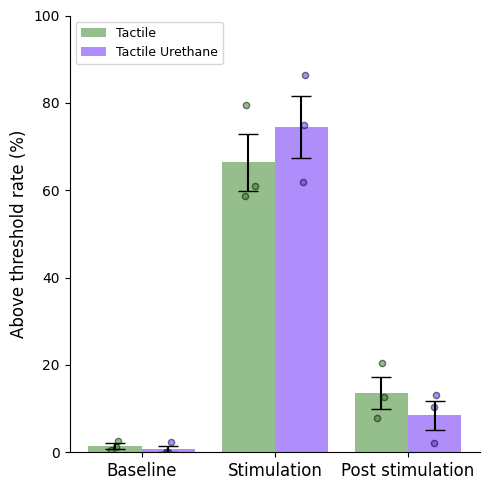

In [10]:
import os
import pandas as pd
import scipy.stats as stats
import scikit_posthocs as sp
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon, shapiro, friedmanchisquare
import numpy as np

# Spécifier le chemin des fichiers Excel
tac_file_path = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Tac_vs_Tac_ure/Thresholding_Tac_vs_Ure/Tac_Norm_response_rate.xlsx'
ure_file_path = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Tac_vs_Tac_ure/Thresholding_Tac_vs_Ure/Tac_ure_Norm_response_rate.xlsx'

# Lecture des fichiers Excel
df_tac = pd.read_excel(tac_file_path)
df_ure = pd.read_excel(ure_file_path)

# Extraire uniquement le type de période (TS, TB, PTS) sans les indices
df_tac['period_type'] = df_tac['period'].str.extract(r'([A-Za-z]+)')
df_ure['period_type'] = df_ure['period'].str.extract(r'([A-Za-z]+)')

# Vérification des tailles d'échantillons : s'assurer que chaque période a bien 24 observations par animal
for df, condition in zip([df_tac, df_ure], ['Tactile', 'ure']):

    # Compter le nombre d'observations par période et par animal
    sample_sizes = df.groupby(['animal', 'period_type']).size().reset_index(name='count')

    # Vérifier si toutes les périodes ont exactement 24 observations par animal
    for period in ['TB', 'TS', 'PTS']:
        period_data = sample_sizes[sample_sizes['period_type'] == period]

# Groupement des données par 'animal', 'period_type' et calcul de la moyenne pour chaque groupe
mean_tac_animal = df_tac.groupby(['animal', 'period_type'])['Norm_response_rate'].mean().reset_index()
mean_ure_animal = df_ure.groupby(['animal', 'period_type'])['Norm_response_rate'].mean().reset_index()

# Moyenne des animaux pour chaque période et condition (pour obtenir 1 valeur moyenne par période)
mean_tac = mean_tac_animal.groupby('period_type')['Norm_response_rate'].mean().reset_index()
sem_tac = mean_tac_animal.groupby('period_type')['Norm_response_rate'].sem().reset_index()

mean_ure = mean_ure_animal.groupby('period_type')['Norm_response_rate'].mean().reset_index()
sem_ure = mean_ure_animal.groupby('period_type')['Norm_response_rate'].sem().reset_index()

# Réorganiser les données dans l'ordre TB, TS, PTS
period_order = ['TB', 'TS', 'PTS']

mean_tac = mean_tac.set_index('period_type').reindex(period_order).reset_index()
sem_tac = sem_tac.set_index('period_type').reindex(period_order).reset_index()

mean_ure = mean_ure.set_index('period_type').reindex(period_order).reset_index()
sem_ure = sem_ure.set_index('period_type').reindex(period_order).reset_index()

# Créer un DataFrame avec les moyennes et sem pour chaque période et chaque condition
mean_response_data = pd.DataFrame({
    'period': ['Baseline', 'Stimulation', 'Post stimulation'],
    'mean_response_tac': mean_tac['Norm_response_rate'],
    'sem_response_tac': sem_tac['Norm_response_rate'],
    'mean_response_ure': mean_ure['Norm_response_rate'],
    'sem_response_ure': sem_ure['Norm_response_rate']
})
# Calcul des moyennes, SEM et tailles d'échantillon pour chaque période
summary_stats = {}

for df, condition in zip([mean_tac_animal, mean_ure_animal], ['Tactile', 'Urethane']):
    condition_stats = {}
    for period in ['TB', 'TS', 'PTS']:
        period_data = df[df['period_type'] == period]['Norm_response_rate']
        mean_val = period_data.mean()
        sem_val = period_data.sem()
        n = len(period_data)
        
        condition_stats[period] = {
            'mean': round(mean_val, 4),
            'sem': round(sem_val, 4),
            'n': n
        }
    summary_stats[condition] = condition_stats

# Impression des moyennes, SEM et tailles d'échantillon
print("\n=== Moyennes ± SEM et tailles d'échantillon ===\n")
for condition, periods in summary_stats.items():
    print(f"Condition: {condition}")
    for period, stats in periods.items():
        print(f"    {period}: {stats['mean']} ± {stats['sem']}, n = {stats['n']}")
    print()

# Effectuer le test de normalité pour chaque période et condition
normality_results = {}
print("\n=== Résultats du test de normalité (Shapiro-Wilk) ===\n")
for df, condition in zip([mean_tac_animal, mean_ure_animal], ['Tactile', 'Urethane']):
    normality_results[condition] = {}
    for period in ['TB', 'TS', 'PTS']:
        period_data = df[df['period_type'] == period]['Norm_response_rate']
        stat, p_value = shapiro(period_data)
        normality_results[condition][period] = {
            'statistic': round(stat, 4),
            'p_value': round(p_value, 4)
        }
        print(f"{condition}-{period} :  Stat = {stat:.4f}, p-value = {p_value:.4f}")

    print()


# Tracer les résultats
plt.figure(figsize=(5, 5))

# Barplot des taux de réponse moyens par période avec sem
bar_width = 0.4
x = range(len(mean_response_data['period']))

# Barres pour la condition Tac
plt.bar([p - bar_width/2 for p in x], mean_response_data['mean_response_tac'],
        width=bar_width, yerr=mean_response_data['sem_response_tac'],
        label='Tactile', color='#2a7e19', alpha=0.5, capsize=7)

# Barres pour la condition ure
plt.bar([p + bar_width/2 for p in x], mean_response_data['mean_response_ure'],
        width=bar_width, yerr=mean_response_data['sem_response_ure'],
        label='Tactile Urethane', color='#601ef9', alpha=0.5, capsize=7)

# Ajouter les points des trials
for period_idx, period in enumerate(['TB', 'TS', 'PTS']):
    # Extraire les valeurs de réponse par animal pour chaque période
    tac_values = mean_tac_animal[mean_tac_animal['period_type'] == period]['Norm_response_rate']
    ure_values = mean_ure_animal[mean_ure_animal['period_type'] == period]['Norm_response_rate']
    # Ajouter une légère variation aléatoire pour les positions en x afin de les distribuer autour des positions des barres
    jitter = 0.05  # ajuster cette valeur pour contrôler l'écart des points

    # Tracer les points pour chaque condition avec un écart autour de la position
    plt.scatter([period_idx - bar_width/2 + np.random.uniform(-jitter, jitter) for _ in tac_values],
                tac_values, color='#2a7e19', edgecolor='black', s=20, alpha=0.5)
    plt.scatter([period_idx + bar_width/2 + np.random.uniform(-jitter, jitter) for _ in ure_values],
                ure_values, color='#601ef9', edgecolor='black', s=20, alpha=0.5)


# Titres et légendes
plt.xlabel('')
# plt.title("Norm_response_rate by conditions (N = trials)")
plt.ylabel("Above threshold rate (%)")
plt.xticks(x, mean_response_data['period'])
# plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='upper left')
plt.ylim(0, 100)

# Enlever les bordures du haut et de droite pour le premier subplot (ax1)
ax = plt.gca()  # Obtenir les axes actuels
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.rcParams.update({
    'axes.titlesize': 12,   # Taille du titre des axes
    'axes.labelsize': 12,   # Taille des labels des axes
    'xtick.labelsize': 12,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 10,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 9   # Taille de la police de la légende
})

# Affichage du graphique
plt.tight_layout()


plt.show()


### 5.2. with n = Trials


Période: TB
Condition tac: Mean = 1.3958 ± SEM = 0.4594, n = 24,               Shapiro-Wilk: Stat = 0.6870, p = 0.0000
Condition ure: Mean = 0.7500 ± SEM = 0.4672, n = 24,               Shapiro-Wilk: Stat = 0.3757, p = 0.0000

Période: TS
Condition tac: Mean = 66.3690 ± SEM = 3.2502, n = 24,               Shapiro-Wilk: Stat = 0.9422, p = 0.1829
Condition ure: Mean = 74.4048 ± SEM = 2.6707, n = 24,               Shapiro-Wilk: Stat = 0.9239, p = 0.0714

Période: PTS
Condition tac: Mean = 13.6458 ± SEM = 1.5322, n = 24,               Shapiro-Wilk: Stat = 0.9593, p = 0.4241
Condition ure: Mean = 8.4896 ± SEM = 1.7947, n = 24,               Shapiro-Wilk: Stat = 0.8337, p = 0.0011


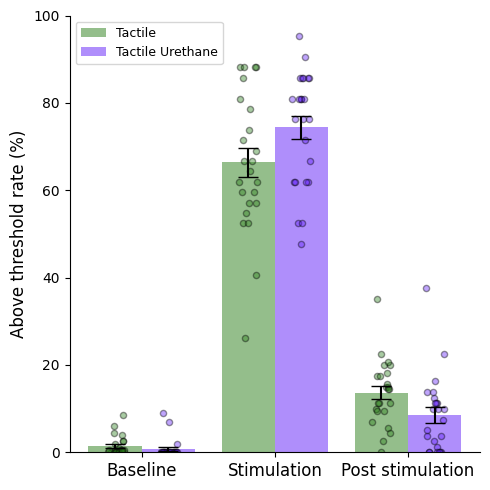

In [15]:
import os
import pandas as pd
import scipy.stats as stats
import scikit_posthocs as sp
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import wilcoxon, shapiro, friedmanchisquare

# Spécifier le chemin des fichiers Excel
tac_file_path = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Tac_vs_Tac_ure/Thresholding_Tac_vs_Ure/Tac_Norm_response_rate.xlsx'
ure_file_path = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Tac_vs_Tac_ure/Thresholding_Tac_vs_Ure/Tac_ure_Norm_response_rate.xlsx'

# Lecture des fichiers Excel
df_tac = pd.read_excel(tac_file_path)
df_ure = pd.read_excel(ure_file_path)

# Extraire uniquement le type de période (TS, TB, PTS) sans les indices
df_tac['period_type'] = df_tac['period'].str.extract(r'([A-Za-z]+)')
df_ure['period_type'] = df_ure['period'].str.extract(r'([A-Za-z]+)')

# Filtrer les données par period_type
df_tac_filtered = df_tac[df_tac['period_type'].isin(['TS', 'TB', 'PTS'])]
df_ure_filtered = df_ure[df_ure['period_type'].isin(['TS', 'TB', 'PTS'])]

# Moyenne des animaux pour chaque période et condition (pour obtenir 1 valeur moyenne par période)
mean_tac = df_tac_filtered.groupby('period_type')['Norm_response_rate'].mean().reset_index()
sem_tac = df_tac_filtered.groupby('period_type')['Norm_response_rate'].sem().reset_index()

mean_ure = df_ure_filtered.groupby('period_type')['Norm_response_rate'].mean().reset_index()
sem_ure = df_ure_filtered.groupby('period_type')['Norm_response_rate'].sem().reset_index()

# Réorganiser les données dans l'ordre TB, TS, PTS
period_order = ['TB', 'TS', 'PTS']

mean_tac = mean_tac.set_index('period_type').reindex(period_order).reset_index()
sem_tac = sem_tac.set_index('period_type').reindex(period_order).reset_index()

mean_ure = mean_ure.set_index('period_type').reindex(period_order).reset_index()
sem_ure = sem_ure.set_index('period_type').reindex(period_order).reset_index()

# Créer un DataFrame avec les moyennes et SEM pour chaque période et chaque condition
mean_response_data = pd.DataFrame({
    'period': ['Baseline', 'Stimulation', 'Post stimulation'],
    'mean_response_tac': mean_tac['Norm_response_rate'],
    'sem_response_tac': sem_tac['Norm_response_rate'],
    'mean_response_ure': mean_ure['Norm_response_rate'],
    'sem_response_ure': sem_ure['Norm_response_rate']
})

# Effectuer le test de normalité pour chaque période et condition
normality_results = {}
for period in ['TB', 'TS', 'PTS']:
    normality_results[period] = {}
    for cond, df_filtered in zip(['tac', 'ure'], [df_tac_filtered, df_ure_filtered]):
        period_data = df_filtered[df_filtered['period_type'] == period]['Norm_response_rate']
        n = len(period_data)
        stat, p_value = shapiro(period_data)
        normality_results[period][cond] = {
            'mean': period_data.mean(),
            'sem': stats.sem(period_data),
            'n': n,
            'shapiro_stat': stat,
            'shapiro_p': p_value
        }

# Affichage des résultats
for period in ['TB', 'TS', 'PTS']:
    print(f"\nPériode: {period}")
    for cond in ['tac', 'ure']:
        res = normality_results[period][cond]
        print(f"Condition {cond}: Mean = {res['mean']:.4f} ± SEM = {res['sem']:.4f}, n = {res['n']}, \
              Shapiro-Wilk: Stat = {res['shapiro_stat']:.4f}, p = {res['shapiro_p']:.4f}")

# Tracer les résultats
plt.figure(figsize=(5, 5))

# Barplot des taux de réponse moyens par période avec sem
bar_width = 0.4
x = range(len(mean_response_data['period']))

# Barres pour la condition tac
plt.bar([p - bar_width/2 for p in x], mean_response_data['mean_response_tac'],
        width=bar_width, yerr=mean_response_data['sem_response_tac'],
        label='Tactile', color='#2a7e19', alpha=0.5, capsize=7)

# Barres pour la condition ure
plt.bar([p + bar_width/2 for p in x], mean_response_data['mean_response_ure'],
        width=bar_width, yerr=mean_response_data['sem_response_ure'],
        label='Tactile Urethane', color='#601ef9', alpha=0.5, capsize=7)

# Ajouter les points des trials
for period_idx, period in enumerate(['TB', 'TS', 'PTS']):
    tac_values = df_tac_filtered[df_tac_filtered['period_type'] == period]['Norm_response_rate']
    ure_values = df_ure_filtered[df_ure_filtered['period_type'] == period]['Norm_response_rate']
    jitter = 0.07
    plt.scatter([period_idx - bar_width/2 + np.random.uniform(-jitter, jitter) for _ in tac_values],
                tac_values, color='#2a7e19', edgecolor='black', s=20, alpha=0.4)
    plt.scatter([period_idx + bar_width/2 + np.random.uniform(-jitter, jitter) for _ in ure_values],
                ure_values, color='#601ef9', edgecolor='black', s=20, alpha=0.4)

# Titres et légendes
plt.xlabel('')
plt.ylabel("Above threshold rate (%)")
plt.xticks(x, mean_response_data['period'])
plt.legend(loc='upper left')
plt.ylim(0, 100)

# Enlever les bordures du haut et de droite
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.rcParams.update({
    'axes.titlesize': 12,
    'axes.labelsize': 12,
    'xtick.labelsize': 12,
    'ytick.labelsize': 10,
    'legend.fontsize': 9
})

plt.tight_layout()
plt.show()


#### Fichier merged Tactile-Urethane above threshold for R stat

In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import friedmanchisquare, wilcoxon
from scikit_posthocs import posthoc_dunn
import matplotlib.lines as mlines


# Chemins vers les fichiers Excel pour chaque variable
tac_file_path = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Tac_vs_Tac_ure/Thresholding_Tac_vs_Ure/Tac_Norm_response_rate.xlsx'
ure_file_path = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Tac_vs_Tac_ure/Thresholding_Tac_vs_Ure/Tac_ure_Norm_response_rate.xlsx'


# Charger les données
df_auc_tac = pd.read_excel(tac_file_path)
df_auc_ure = pd.read_excel(ure_file_path)

# Ajouter une colonne pour identifier la condition
df_auc_tac['Condition'] = 'Tac'
df_auc_ure['Condition'] = 'Ure'

# Extraire le type de période (TB, TS, PTS)
df_auc_tac['Period_type'] = df_auc_tac['period'].str.extract(r'([A-Za-z]+)')
df_auc_ure['Period_type'] = df_auc_ure['period'].str.extract(r'([A-Za-z]+)')

# Fusionner les deux datasets en un seul pour simplifier la gestion
df_combined = pd.concat([df_auc_tac, df_auc_ure], ignore_index=True)

# Définir les périodes
Periods = ['TB', 'TS', 'PTS']


# Filtrer les données par période pour chaque variable
df_Periods = {
    'Tactile': {Period: df_combined[(df_combined['Period_type'] == Period) & (df_combined['Condition'] == 'Tac')] for Period in Periods},
    'Ure': {Period: df_combined[(df_combined['Period_type'] == Period) & (df_combined['Condition'] == 'Ure')] for Period in Periods},
}

# Chemin pour le fichier Excel de sortie
output_file = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Tac_vs_Tac_ure/Thresholding_Tac_vs_Ure/Above_Threshold_Combined_tac_ure.xlsx'

# Sauvegarder le DataFrame dans un fichier Excel
df_combined.to_excel(output_file, index=False)

print(f"Le DataFrame df_combined a été sauvegardé dans le fichier : {output_file}")


Le DataFrame df_combined a été sauvegardé dans le fichier : G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Tac_vs_Tac_ure/Thresholding_Tac_vs_Ure/Above_Threshold_Combined_tac_ure.xlsx


# 6. Magnitude of the response

### 6.1. N = animals 


--- Résultats : Moyennes, SEM et Tailles d'échantillons ---
Tactile - TB: Mean = 0.0405 ± 0.0227, n = 3
Tactile - TS: Mean = 2.6694 ± 0.2432, n = 3
Tactile - PTS: Mean = 0.4020 ± 0.1379, n = 3
Tactile Urethane - TB: Mean = 0.0298 ± 0.0298, n = 3
Tactile Urethane - TS: Mean = 3.5076 ± 0.3406, n = 3
Tactile Urethane - PTS: Mean = 0.2597 ± 0.1126, n = 3

--- Test de normalité (Shapiro-Wilk) ---
Tac - TB: n = 3, Statistique = 0.9099, p-value = 0.4177
Ure - TB: n = 3, Statistique = 0.7500, p-value = 0.0000
Tac - TS: n = 3, Statistique = 0.9111, p-value = 0.4217
Ure - TS: n = 3, Statistique = 0.9943, p-value = 0.8557
Tac - PTS: n = 3, Statistique = 0.9582, p-value = 0.6066
Ure - PTS: n = 3, Statistique = 0.9769, p-value = 0.7085


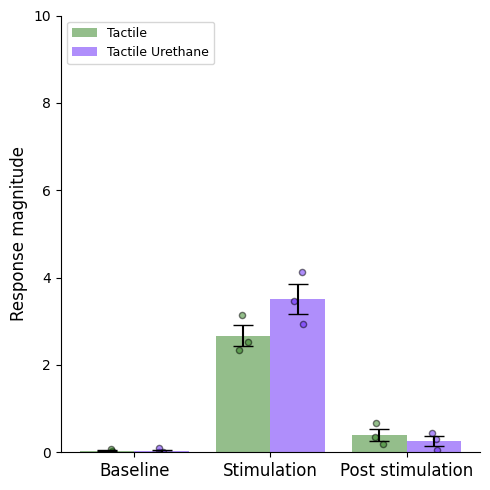

In [13]:
import os
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import shapiro

# Spécifier le chemin des fichiers Excel
tac_file_path = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Tac_vs_Tac_ure/Thresholding_Tac_vs_Ure/Tac_Response_Magnitude.xlsx'
ure_file_path = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Tac_vs_Tac_ure/Thresholding_Tac_vs_Ure/Tac_ure_Response_Magnitude.xlsx'

# Lecture des fichiers Excel
df_tac = pd.read_excel(tac_file_path)
df_ure = pd.read_excel(ure_file_path)

# Extraire uniquement le type de période (TS, TB, PTS) sans les indices
df_tac['period_type'] = df_tac['period'].str.extract(r'([A-Za-z]+)')
df_ure['period_type'] = df_ure['period'].str.extract(r'([A-Za-z]+)')

# Groupement des données par 'animal', 'period_type' et calcul de la moyenne pour chaque groupe
mean_tac_animal = df_tac.groupby(['animal', 'period_type'])['response_magnitude'].mean().reset_index()
mean_ure_animal = df_ure.groupby(['animal', 'period_type'])['response_magnitude'].mean().reset_index()

# Moyenne des animaux pour chaque période et condition
mean_tac = mean_tac_animal.groupby('period_type')['response_magnitude'].mean().reset_index()
sem_tac = mean_tac_animal.groupby('period_type')['response_magnitude'].sem().reset_index()
n_tac = mean_tac_animal.groupby('period_type')['response_magnitude'].size().reset_index(name='n')

mean_ure = mean_ure_animal.groupby('period_type')['response_magnitude'].mean().reset_index()
sem_ure = mean_ure_animal.groupby('period_type')['response_magnitude'].sem().reset_index()
n_ure = mean_ure_animal.groupby('period_type')['response_magnitude'].size().reset_index(name='n')

# Réorganiser les données dans l'ordre TB, TS, PTS
period_order = ['TB', 'TS', 'PTS']
mean_tac = mean_tac.set_index('period_type').reindex(period_order).reset_index()
sem_tac = sem_tac.set_index('period_type').reindex(period_order).reset_index()
n_tac = n_tac.set_index('period_type').reindex(period_order).reset_index()

mean_ure = mean_ure.set_index('period_type').reindex(period_order).reset_index()
sem_ure = sem_ure.set_index('period_type').reindex(period_order).reset_index()
n_ure = n_ure.set_index('period_type').reindex(period_order).reset_index()

# Impression des moyennes ± SEM et tailles d'échantillons
print("\n--- Résultats : Moyennes, SEM et Tailles d'échantillons ---")
for period, mean, sem, n in zip(mean_tac['period_type'], mean_tac['response_magnitude'], sem_tac['response_magnitude'], n_tac['n']):
    print(f"Tactile - {period}: Mean = {mean:.4f} ± {sem:.4f}, n = {n}")

for period, mean, sem, n in zip(mean_ure['period_type'], mean_ure['response_magnitude'], sem_ure['response_magnitude'], n_ure['n']):
    print(f"Tactile Urethane - {period}: Mean = {mean:.4f} ± {sem:.4f}, n = {n}")

# Test de normalité (Shapiro-Wilk) pour chaque période et condition
print("\n--- Test de normalité (Shapiro-Wilk) ---")
normality_results = {}
for period in period_order:
    normality_results[period] = {}
    for cond, data in [('tac', mean_tac_animal), ('ure', mean_ure_animal)]:
        period_data = data[data['period_type'] == period]['response_magnitude']
        n = len(period_data)
        stat, p_value = shapiro(period_data)
        normality_results[period][cond] = {'statistic': stat, 'p_value': p_value}
        print(f"{cond.capitalize()} - {period}: n = {n}, Statistique = {stat:.4f}, p-value = {p_value:.4f}")
# Tracer les résultats
plt.figure(figsize=(5, 5))

# Barplot des taux de réponse moyens par période avec sem
bar_width = 0.4
x = range(len(mean_response_data['period']))

# Barres pour la condition tac
plt.bar([p - bar_width/2 for p in x], mean_response_data['mean_response_tac'],
        width=bar_width, yerr=mean_response_data['sem_response_tac'],
        label='Tactile', color='#2a7e19', alpha=0.5, capsize=7)

# Barres pour la condition ure
plt.bar([p + bar_width/2 for p in x], mean_response_data['mean_response_ure'],
        width=bar_width, yerr=mean_response_data['sem_response_ure'],
        label='Tactile Urethane', color='#601ef9', alpha=0.5, capsize=7)

# Ajouter les points des trials
for period_idx, period in enumerate(['TB', 'TS', 'PTS']):
    # Extraire les valeurs de réponse par animal pour chaque période
    tac_values = mean_tac_animal[mean_tac_animal['period_type'] == period]['response_magnitude']
    ure_values = mean_ure_animal[mean_ure_animal['period_type'] == period]['response_magnitude']
    # Ajouter une légère variation aléatoire pour les positions en x afin de les distribuer autour des positions des barres
    jitter = 0.05  # ajuster cette valeur pour contrôler l'écart des points

    # Tracer les points pour chaque condition avec un écart autour de la position
    plt.scatter([period_idx - bar_width/2 + np.random.uniform(-jitter, jitter) for _ in tac_values],
                tac_values, color='#2a7e19', edgecolor='black', s=20, alpha=0.5)
    plt.scatter([period_idx + bar_width/2 + np.random.uniform(-jitter, jitter) for _ in ure_values],
                ure_values, color='#601ef9', edgecolor='black', s=20, alpha=0.5)


# Titres et légendes
plt.xlabel('')
# plt.title("response_magnitude by conditions (N = trials)")
plt.ylabel("Response magnitude")
plt.xticks(x, mean_response_data['period'])
# plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='upper left')
plt.ylim(0, 10)

# Enlever les bordures du haut et de droite pour le premier subplot (ax1)
ax = plt.gca()  # Obtenir les axes actuels
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.rcParams.update({
    'axes.titlesize': 12,   # Taille du titre des axes
    'axes.labelsize': 12,   # Taille des labels des axes
    'xtick.labelsize': 12,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 10,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 9   # Taille de la police de la légende
})

# Affichage du graphique
plt.tight_layout()

### 6.2. N = Trials


Statistiques des réponses par condition et période :

Condition Period   Mean    SEM  n  Shapiro Stat  Shapiro p-value
      tac     TB 0.0405 0.0151 24        0.6160           0.0000
      ure     TB 0.0298 0.0195 24        0.3549           0.0000
      tac     TS 2.6694 0.1366 24        0.9590           0.4193
      ure     TS 3.5076 0.1616 24        0.9408           0.1699
      tac    PTS 0.4020 0.0552 24        0.9004           0.0220
      ure    PTS 0.2597 0.0671 24        0.7270           0.0000


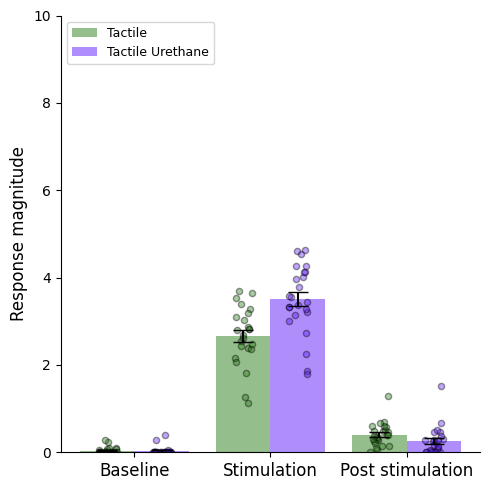

In [16]:
import os
import pandas as pd
import scipy.stats as stats
import scikit_posthocs as sp
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import wilcoxon, shapiro, friedmanchisquare

# Spécifier le chemin des fichiers Excel
tac_file_path = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Tac_vs_Tac_ure/Thresholding_Tac_vs_Ure/Tac_Response_Magnitude.xlsx'
ure_file_path = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Tac_vs_Tac_ure/Thresholding_Tac_vs_Ure/Tac_ure_Response_Magnitude.xlsx'

# Lecture des fichiers Excel
df_tac = pd.read_excel(tac_file_path)
df_ure = pd.read_excel(ure_file_path)

# Extraire uniquement le type de période (TS, TB, PTS) sans les indices
df_tac['period_type'] = df_tac['period'].str.extract(r'([A-Za-z]+)')
df_ure['period_type'] = df_ure['period'].str.extract(r'([A-Za-z]+)')

# Filtrer les données par period_type
df_tac_filtered = df_tac[df_tac['period_type'].isin(['TS', 'TB', 'PTS'])]
df_ure_filtered = df_ure[df_ure['period_type'].isin(['TS', 'TB', 'PTS'])]

# Calcul des statistiques : moyenne, SEM et taille d'échantillon (n)
summary_stats = []
for period in ['TB', 'TS', 'PTS']:
    for cond, df_filtered in zip(['tac', 'ure'], [df_tac_filtered, df_ure_filtered]):
        period_data = df_filtered[df_filtered['period_type'] == period]['response_magnitude']
        mean = period_data.mean()
        sem = stats.sem(period_data)
        n = len(period_data)
        stat, p_value = shapiro(period_data)
        
        # Ajouter les statistiques au tableau de résultat
        summary_stats.append({
            'Condition': cond,
            'Period': period,
            'Mean': round(mean, 4),
            'SEM': round(sem, 4),
            'n': n,
            'Shapiro Stat': round(stat, 4),
            'Shapiro p-value': round(p_value, 4)
        })

# Création d'un DataFrame pour afficher les statistiques
df_summary = pd.DataFrame(summary_stats)
print("\nStatistiques des réponses par condition et période :\n")
print(df_summary.to_string(index=False))

# Moyenne des animaux pour chaque période et condition (pour obtenir 1 valeur moyenne par période)
mean_tac = df_tac_filtered.groupby('period_type')['response_magnitude'].mean().reset_index()
sem_tac = df_tac_filtered.groupby('period_type')['response_magnitude'].sem().reset_index()

mean_ure = df_ure_filtered.groupby('period_type')['response_magnitude'].mean().reset_index()
sem_ure = df_ure_filtered.groupby('period_type')['response_magnitude'].sem().reset_index()

# Réorganiser les données dans l'ordre TB, TS, PTS
period_order = ['TB', 'TS', 'PTS']

mean_tac = mean_tac.set_index('period_type').reindex(period_order).reset_index()
sem_tac = sem_tac.set_index('period_type').reindex(period_order).reset_index()

mean_ure = mean_ure.set_index('period_type').reindex(period_order).reset_index()
sem_ure = sem_ure.set_index('period_type').reindex(period_order).reset_index()

# Créer un DataFrame avec les moyennes et sem pour chaque période et chaque condition
mean_response_data = pd.DataFrame({
    'period': ['Baseline', 'Stimulation', 'Post stimulation'],
    'mean_response_tac': mean_tac['response_magnitude'],
    'sem_response_tac': sem_tac['response_magnitude'],
    'mean_response_ure': mean_ure['response_magnitude'],
    'sem_response_ure': sem_ure['response_magnitude']
})

# Tracer les résultats
plt.figure(figsize=(5, 5))

# Barplot des taux de réponse moyens par période avec sem
bar_width = 0.4
x = range(len(mean_response_data['period']))

# Barres pour la condition tac
plt.bar([p - bar_width/2 for p in x], mean_response_data['mean_response_tac'],
        width=bar_width, yerr=mean_response_data['sem_response_tac'],
        label='Tactile', color='#2a7e19', alpha=0.5, capsize=7)

# Barres pour la condition ure
plt.bar([p + bar_width/2 for p in x], mean_response_data['mean_response_ure'],
        width=bar_width, yerr=mean_response_data['sem_response_ure'],
        label='Tactile Urethane', color='#601ef9', alpha=0.5, capsize=7)

# Ajouter les points des trials
for period_idx, period in enumerate(['TB', 'TS', 'PTS']):
    tac_values = df_tac_filtered[df_tac_filtered['period_type'] == period]['response_magnitude']
    ure_values = df_ure_filtered[df_ure_filtered['period_type'] == period]['response_magnitude']

    jitter = 0.07  # Variation pour éviter la superposition
    plt.scatter([period_idx - bar_width/2 + np.random.uniform(-jitter, jitter) for _ in tac_values],
                tac_values, color='#2a7e19', edgecolor='black', s=20, alpha=0.4)
    plt.scatter([period_idx + bar_width/2 + np.random.uniform(-jitter, jitter) for _ in ure_values],
                ure_values, color='#601ef9', edgecolor='black', s=20, alpha=0.4)

# Titres et légendes
plt.xlabel('')
plt.ylabel("Response magnitude")
plt.xticks(x, mean_response_data['period'])
plt.legend(loc='upper left')
plt.ylim(0, 10)

# Enlever les bordures du haut et de droite
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Mise à jour des paramètres d'affichage
plt.rcParams.update({
    'axes.titlesize': 12,
    'axes.labelsize': 12,
    'xtick.labelsize': 12,
    'ytick.labelsize': 10,
    'legend.fontsize': 9
})

# Affichage du graphique
plt.tight_layout()
plt.show()


#### Fichier merged Tactile-Urethane response magnitude for R stat

In [6]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import friedmanchisquare, wilcoxon
from scikit_posthocs import posthoc_dunn
import matplotlib.lines as mlines


# Chemins vers les fichiers Excel pour chaque variable
tac_file_path = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Tac_vs_Tac_ure/Thresholding_Tac_vs_Ure/Tac_Response_Magnitude.xlsx'
ure_file_path = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Tac_vs_Tac_ure/Thresholding_Tac_vs_Ure/Tac_ure_Response_Magnitude.xlsx'


# Charger les données
df_auc_tac = pd.read_excel(tac_file_path)
df_auc_ure = pd.read_excel(ure_file_path)

# Ajouter une colonne pour identifier la condition
df_auc_tac['Condition'] = 'Tac'
df_auc_ure['Condition'] = 'Ure'

# Extraire le type de période (TB, TS, PTS)
df_auc_tac['Period_type'] = df_auc_tac['period'].str.extract(r'([A-Za-z]+)')
df_auc_ure['Period_type'] = df_auc_ure['period'].str.extract(r'([A-Za-z]+)')

# Fusionner les deux datasets en un seul pour simplifier la gestion
df_combined = pd.concat([df_auc_tac, df_auc_ure], ignore_index=True)

# Définir les périodes
Periods = ['TB', 'TS', 'PTS']


# Filtrer les données par période pour chaque variable
df_Periods = {
    'Tactile': {Period: df_combined[(df_combined['Period_type'] == Period) & (df_combined['Condition'] == 'Tac')] for Period in Periods},
    'Ure': {Period: df_combined[(df_combined['Period_type'] == Period) & (df_combined['Condition'] == 'Ure')] for Period in Periods},
}

# Chemin pour le fichier Excel de sortie
output_file = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Tac_vs_Tac_ure/Thresholding_Tac_vs_Ure/Resp_magnitude_Combined_tac_ure.xlsx'

# Sauvegarder le DataFrame dans un fichier Excel
df_combined.to_excel(output_file, index=False)

print(f"Le DataFrame df_combined a été sauvegardé dans le fichier : {output_file}")


Le DataFrame df_combined a été sauvegardé dans le fichier : G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Tac_vs_Tac_ure/Thresholding_Tac_vs_Ure/Resp_magnitude_Combined_tac_ure.xlsx


# 7. Combo heatmap - PTSC

La valeur maximale de Znorm entre 0 et 2.1 s  est : 9.551013838556234


C:\Users\zayan\AppData\Local\Temp\ipykernel_63852\3765416081.py:79: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df_heatmap_combined = df_tac.pivot_table(index='Stim', columns='Stim_Time_sec', values='Znorm', aggfunc='mean')
C:\Users\zayan\AppData\Local\Temp\ipykernel_63852\3765416081.py:280: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


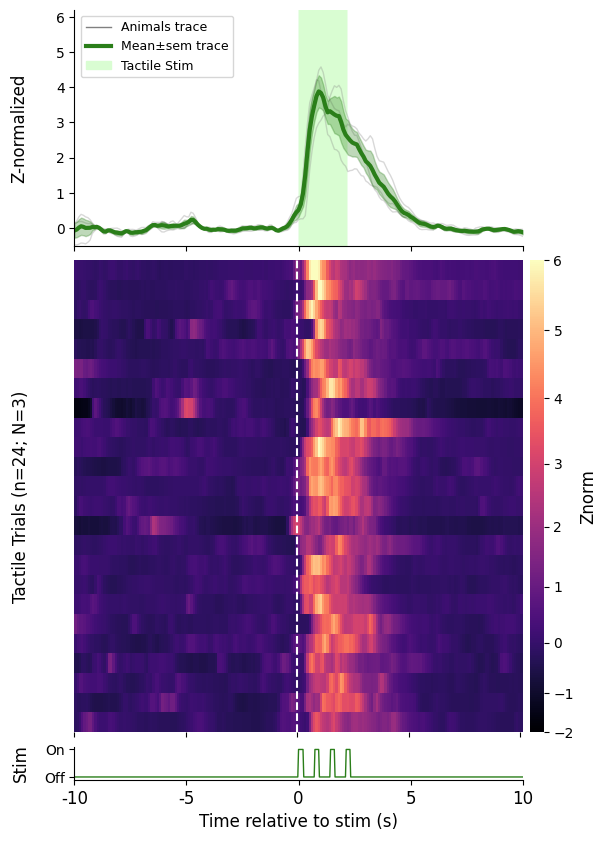

In [17]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import PowerNorm
from matplotlib.colors import Normalize
import os
import glob


########################################################## PSTC #####################################################################


# Répertoire contenant les fichiers Excel
input_directory = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Tac_vs_Tac_ure/Df_tac_Trial_Mean_SEM/'

# Trouver tous les fichiers correspondant au modèle
file_pattern = os.path.join(input_directory, 'Df_Zscore_classic_tac_*_trial_mean_SEM.xlsx')
files = glob.glob(file_pattern)

# Charger et combiner les données de tous les fichiers
dfs = []
for file_path in files:
    df = pd.read_excel(file_path)
    # Extraire la date et la partie du nom de fichier à partir du chemin du fichier Excel
    file_name = os.path.basename(file_path)
    save_file_name = file_name.split('_', 2)[2].replace('.xlsx', '')  # Garder la partie "2023.10.07_trial_mean"
    df['FileName'] = save_file_name
    dfs.append(df)
df_combined = pd.concat(dfs, ignore_index=True)

# Ajouter une colonne 'time_sec' en convertissant 'Stim_Time' en secondes
df_combined['time_sec'] = df_combined['Stim_Time'] / 1000  # Conversion de Stim_Time en secondes


########################################################## HEATMAP #####################################################################

# Lire le fichier Excel
file_path_tac = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Tac_vs_Tac_ure/Df_Zscore_classic_tac_stim.xlsx'
df_tac = pd.read_excel(file_path_tac)

# # Trouver la valeur maximale de la colonne 'Znorm'
# max_znorm_value = df_tac['Znorm'].max()
# print("La valeur maximale de Znorm est :", max_znorm_value)

# Ajouter une colonne 'Stim' avec des identifiants uniques pour chaque trial
def add_stim_column(df, condition):
    trials_unique = df[['animal', 'trial']].drop_duplicates().reset_index(drop=True)
    trial_mapping = {idx: f'Stim_{idx+1}_{condition}' for idx in range(trials_unique.shape[0])}
    df['Stim'] = df.apply(lambda row: trial_mapping[trials_unique[(trials_unique['animal'] == row['animal']) & 
                                                                  (trials_unique['trial'] == row['trial'])].index[0]], axis=1)
    df['Condition'] = condition  # Ajouter une colonne Condition

add_stim_column(df_tac, 'Tactile')

# Convertir Stim_Time en secondes
df_tac['Stim_Time_sec'] = df_tac['Stim_Time'] / 1000

# Filtrer les données pour les time_sec compris entre 0 et 3.9
df_filtered = df_tac[(df_tac['Stim_Time_sec'] >= 0) & (df_tac['Stim_Time_sec'] <= 2.1)]

# Trouver la valeur maximale de la colonne 'Z-score_norm' dans l'intervalle filtré
max_znorm_value = df_filtered['Znorm'].max()

print("La valeur maximale de Znorm entre 0 et 2.1 s  est :", max_znorm_value)


# Filtrer et calculer la somme de Znorm pour Stim_Time_sec entre 0 et 10 s, pour trier les trials
df_tac_filtered = df_tac[(df_tac['Stim_Time_sec'] >= 0) & (df_tac['Stim_Time_sec'] <= 10)]
trial_sums = df_tac_filtered.groupby('Stim')['Znorm'].max().sort_values(ascending=False)

# Réorganiser le DataFrame initial en fonction des trials triés par Znorm total
df_tac['Stim'] = pd.Categorical(df_tac['Stim'], categories=trial_sums.index, ordered=True)
df_tac = df_tac.sort_values('Stim')

# Créer la heatmap pour le DataFrame trié
df_heatmap_combined = df_tac.pivot_table(index='Stim', columns='Stim_Time_sec', values='Znorm', aggfunc='mean')
df_heatmap_combined = df_heatmap_combined.join(df_tac[['Stim', 'Condition']].drop_duplicates().set_index('Stim'))


########################################################## FIGURE #####################################################################


# Création de la figure avec GridSpec pour inclure le nouveau plot
fig = plt.figure(figsize=(7, 10))
gs = gridspec.GridSpec(nrows=3, ncols=2, width_ratios=[10, 1], height_ratios=[5, 10, 0.7], hspace=0.06)

######## PLOTING - PTSC ########

ax0 = plt.subplot(gs[0, 0])

# Définir les couleurs pour la période "TS"
color_ts = '#d9fdd2'  # light light blue

# Tracer les courbes pour chaque fichier en gris
unique_files = df_combined['FileName'].unique()
for file_name in unique_files:
    df_file = df_combined[df_combined['FileName'] == file_name]
    
    # Couleur gris pour toutes les courbes individuelles
    gray_color = 'gray'
    
    # Tracer la courbe du Mean Znorm
    sns.lineplot(
        data=df_file, x='time_sec', y='Mean_Znorm', 
        color=gray_color, linewidth=1, ax=ax0, alpha=0.3, label=None  # Pas de label pour chaque courbe
    )

# Suppression des duplicatas dans les légendes
ax0.plot([], [], color=gray_color, linewidth=1, label='Animals trace')  # Légende unique

# Calculer la courbe moyenne des animaux
mean_zscore = df_combined.groupby('time_sec')['Mean_Znorm'].mean().reset_index()
ax0.plot(
    mean_zscore['time_sec'], mean_zscore['Mean_Znorm'], 
    color='#2a7e19', linewidth=3, linestyle='-', label='Mean±sem trace'
)

# Calculer la SEM de la courbe moyenne des animaux
SEM_zscore = df_combined.groupby('time_sec')['Mean_Znorm'].sem().reset_index()

# Tracer l'ombre correspondant à SEM autour de Mean_Znorm
ax0.fill_between(
    mean_zscore['time_sec'], 
    mean_zscore['Mean_Znorm'] - SEM_zscore['Mean_Znorm'], 
    mean_zscore['Mean_Znorm'] + SEM_zscore['Mean_Znorm'], 
    color='#2a7e19', alpha=0.3, zorder=2, label=None
)

# Calculer les limites réelles pour l'axe y
y_min = df_combined['Mean_Znorm'].min()
y_max = df_combined['Mean_Znorm'].max()

# Tracer la période TS en arrière-plan
in_ts_period = False
start_time = None
for i, row in df_combined.iterrows():
    if row['period'] == 'TS':
        if not in_ts_period:
            start_time = row['time_sec']
            in_ts_period = True
    elif in_ts_period:
        end_time = row['time_sec']
        
        # Remplir la zone pour la période TS
        ax0.fill_between(
            df_combined['time_sec'], 
            y_min - 2 ,  # Limite inférieure réelle du graphique
            y_max + 10,  # Limite supérieure réelle du graphique
            where=(df_combined['time_sec'] >= start_time) & (df_combined['time_sec'] <= end_time),
            color=color_ts, alpha=0.3, zorder=1
        )
        
        in_ts_period = False


# Ajouter une seule entrée de légende pour "Thermic Stim"
ax0.fill_between(
    [], [], color=color_ts, alpha=1, label='Tactile Stim', zorder=1
)

# Ajuster les ticks et les légendes
ax0.set_ylabel('Z-normalized', labelpad = 20)
ax0.legend(loc = 'upper left')
ax0.set_xlim(-10, 10)
ax0.set_ylim(-0.5, 6.2)
ax0.set_xticks(range(-10, 11, 5))
ax0.set_xticklabels("")

# Enlever les bordures du haut et de droite
ax0.spines['top'].set_visible(False)
ax0.spines['right'].set_visible(False)


######## PLOTING - Heatmap ########

ax1 = plt.subplot(gs[1, 0])
cbar_ax = plt.subplot(gs[1, 1])

# Créer un gradient personnalisé de couleurs avec une normalisation
norm = PowerNorm(gamma=1.2, vmin=-2, vmax=6)
base_palette = sns.color_palette("magma", as_cmap=True)
heatmap_combined = sns.heatmap(df_heatmap_combined.drop(columns=['Condition']),
                               cmap=base_palette, norm=norm, cbar_ax=cbar_ax, ax=ax1)

# Ligne verticale pour marquer 0
ax1.axvline(x=df_heatmap_combined.columns.get_loc(0), color='white', linestyle='--', linewidth=1.5)


# Ajuster la colorbar
cbar = heatmap_combined.collections[0].colorbar
cbar.set_label('Znorm')
cbar.ax.tick_params(labelsize=10)  # Ajuster la taille des labels si nécessaire

# Calculer la position et la hauteur de la heatmap pour ajuster la colorbar
pos = ax1.get_position()  # [x0, y0, width, height]
cbar_ax.set_position([pos.x1 + 0.01, pos.y0, 0.02, pos.y1 - pos.y0])


# Définir les étiquettes de l'axe x (de -10 à 10 avec un pas de 5)
ax1.set_xticks([df_heatmap_combined.columns.get_loc(x) for x in [-10, -5, 0, 5, 10]])

ax1.set_yticks([])  # Supprimer les étiquettes de l'axe y
ax1.set_ylabel('')  # Supprimer les étiquettes de l'axe y

# Marquer les trials Tactile
num_tac_trials = len(df_heatmap_combined[df_heatmap_combined['Condition'] == 'Tactile'])
ax1.text(-20, num_tac_trials / 2, f'Tactile Trials (n={num_tac_trials}; N=3)', fontsize=12, color='black', va='center', ha='right', rotation='vertical')


################# Tactile stim #################

ax2 = plt.subplot(gs[2, 0])

# Initialiser la série temporelle pour les pulses
time_series = np.linspace(-10, 10, len(df_combined))  # Représentation de la série temporelle pour toute la période
pulse_series = np.zeros_like(time_series)

# Paramètres des pulses
pulse_width = 0.2  # Largeur d'un pulse (en secondes) réduite
num_pulses = 4  # Nombre de pulses par stimulation

# Ajouter les pulses dans la série temporelle, en prenant la période "TS" du premier subplot
in_ts_period = False
start_time = None
for i, row in df_combined.iterrows():
    if row['period'] == 'TS':
        if not in_ts_period:
            start_time = row['time_sec']
            in_ts_period = True
    elif in_ts_period:
        end_time = row['time_sec']
        
        # Remplir la zone pour la période TS dans le subplot 2 (ax2)
        pulse_times = np.linspace(start_time, end_time, num_pulses)
        for pulse_time in pulse_times:
            pulse_indices = np.where((time_series >= pulse_time) & (time_series < pulse_time + pulse_width))[0]
            pulse_series[pulse_indices] = 1  # Définir la hauteur du pulse
            
        in_ts_period = False

# Si la période TS se termine à la dernière ligne
if in_ts_period:
    end_time = df_combined['time_sec'].iloc[-1]
    pulse_times = np.linspace(start_time, end_time, num_pulses)
    for pulse_time in pulse_times:
        pulse_indices = np.where((time_series >= pulse_time) & (time_series < pulse_time + pulse_width))[0]
        pulse_series[pulse_indices] = 1  # Définir la hauteur du pulse

# Tracer les pulses sur le deuxième subplot
ax2.plot(time_series, pulse_series, color='#2a7e19', linewidth=1)

# Ajuster les labels et l'échelle
ax2.set_xlabel('Time relative to stim (s)')
ax2.set_ylabel('Stim', labelpad = 10)
ax2.set_xticks(range(-10, 11, 5))
ax2.set_xlim(-10, 10)
ax2.set_xticklabels([str(i) for i in range(-10, 11, 5)])
ax2.set_yticks([0, 1])
ax2.set_ylim(-0.1, 1.1)  # Ajuster pour rendre les pulses visibles
ax2.set_yticklabels(['Off', 'On'])

# Enlever les bordures du haut et de droite pour le deuxième subplot (ax2)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)


# Ajuster les tailles de polices globales
plt.rcParams.update({
    'axes.titlesize': 12,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 9
})

# Ajuster les marges et sauvegarder
plt.tight_layout()

plt.show()


La valeur maximale de Znorm entre 0 et 2.1 s  est : 9.551013838556234
La valeur min de Znorm entre 0 et 2.1 s  est : -0.5665473856431182


C:\Users\zayan\AppData\Local\Temp\ipykernel_63852\1769871696.py:86: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df_heatmap_combined = df_tac_ure.pivot_table(index='Stim', columns='Stim_Time_sec', values='Znorm', aggfunc='mean')
C:\Users\zayan\AppData\Local\Temp\ipykernel_63852\1769871696.py:297: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


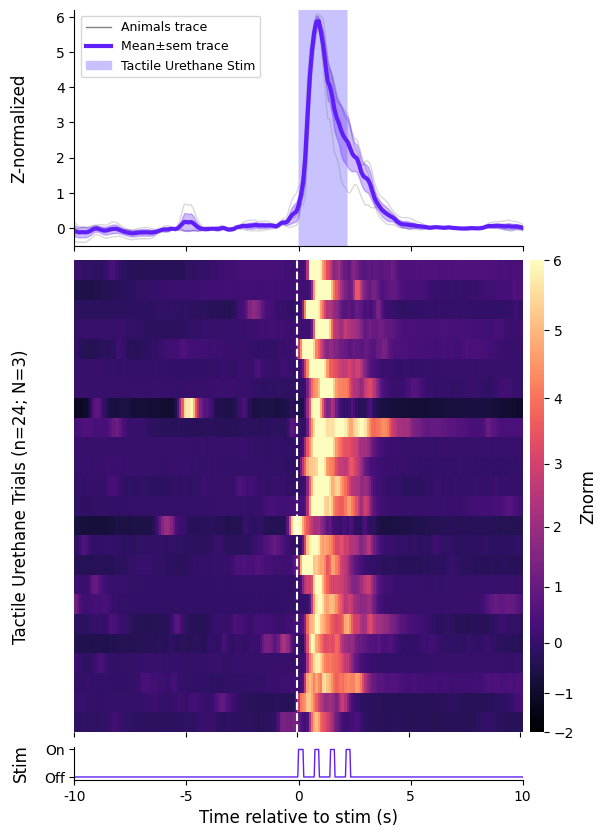

In [18]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import PowerNorm
from matplotlib.colors import Normalize
import os
import glob


########################################################## PSTC #####################################################################


# Répertoire contenant les fichiers Excel
input_directory = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Tac_vs_Tac_ure/Df_tac_ure_Trial_Mean_SEM/'

# Trouver tous les fichiers correspondant au modèle
file_pattern = os.path.join(input_directory, 'Df_Zscore_classic_tac_ure_*_trial_mean_SEM.xlsx')
files = glob.glob(file_pattern)

# Charger et combiner les données de tous les fichiers
dfs = []
for file_path in files:
    df = pd.read_excel(file_path)
    # Extraire la date et la partie du nom de fichier à partir du chemin du fichier Excel
    file_name = os.path.basename(file_path)
    save_file_name = file_name.split('_', 2)[2].replace('.xlsx', '')  # Garder la partie "2023.10.07_trial_mean"
    df['FileName'] = save_file_name
    dfs.append(df)
df_combined = pd.concat(dfs, ignore_index=True)

# Ajouter une colonne 'time_sec' en convertissant 'Stim_Time' en secondes
df_combined['time_sec'] = df_combined['Stim_Time'] / 1000  # Conversion de Stim_Time en secondes


########################################################## HEATMAP #####################################################################

# Lire le fichier Excel
file_path_tac_ure = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_Tac_vs_Tac_ure/Df_Zscore_classic_tac_ure_stim.xlsx'
df_tac_ure = pd.read_excel(file_path_tac_ure)

# # Trouver la valeur maximale de la colonne 'Znorm'
# max_znorm_value = df_tac['Znorm'].max()
# print("La valeur maximale de Znorm est :", max_znorm_value)

# Ajouter une colonne 'Stim' avec des identifiants uniques pour chaque trial
def add_stim_column(df, condition):
    trials_unique = df[['animal', 'trial']].drop_duplicates().reset_index(drop=True)
    trial_mapping = {idx: f'Stim_{idx+1}_{condition}' for idx in range(trials_unique.shape[0])}
    df['Stim'] = df.apply(lambda row: trial_mapping[trials_unique[(trials_unique['animal'] == row['animal']) & 
                                                                  (trials_unique['trial'] == row['trial'])].index[0]], axis=1)
    df['Condition'] = condition  # Ajouter une colonne Condition

add_stim_column(df_tac_ure, 'Tactile')

# Convertir Stim_Time en secondes
df_tac_ure['Stim_Time_sec'] = df_tac_ure['Stim_Time'] / 1000


# Filtrer les données pour les time_sec compris entre 0 et 3.9
df_filtered_ure = df_tac_ure[(df_tac_ure['Stim_Time_sec'] >= 0) & (df_tac_ure['Stim_Time_sec'] <= 2.1)]

# Trouver la valeur maximale de la colonne 'Z-score_norm' dans l'intervalle filtré
max_znorm_value = df_filtered_ure['Znorm'].max()

print("La valeur maximale de Znorm entre 0 et 2.1 s  est :", max_znorm_value)


# Trouver la valeur maximale de la colonne 'Z-score_norm' dans l'intervalle filtré
min_znorm_value = df_filtered_ure['Znorm'].min()

print("La valeur min de Znorm entre 0 et 2.1 s  est :", min_znorm_value)


# Filtrer et calculer la somme de Znorm pour Stim_Time_sec entre 0 et 10 s, pour trier les trials
df_tac_filtered = df_tac_ure[(df_tac_ure['Stim_Time_sec'] >= 0) & (df_tac_ure['Stim_Time_sec'] <= 10)]
trial_sums = df_tac_filtered.groupby('Stim')['Znorm'].max().sort_values(ascending=False)

# Réorganiser le DataFrame initial en fonction des trials triés par Znorm total
df_tac_ure['Stim'] = pd.Categorical(df_tac_ure['Stim'], categories=trial_sums.index, ordered=True)
df_tac_ure = df_tac_ure.sort_values('Stim')

# Créer la heatmap pour le DataFrame trié
df_heatmap_combined = df_tac_ure.pivot_table(index='Stim', columns='Stim_Time_sec', values='Znorm', aggfunc='mean')
df_heatmap_combined = df_heatmap_combined.join(df_tac_ure[['Stim', 'Condition']].drop_duplicates().set_index('Stim'))


########################################################## FIGURE #####################################################################


# Création de la figure avec GridSpec pour inclure le nouveau plot
fig = plt.figure(figsize=(7, 10))
gs = gridspec.GridSpec(nrows=3, ncols=2, width_ratios=[10, 1], height_ratios=[5, 10, 0.7], hspace=0.06)

######## PLOTING - PTSC ########

ax0 = plt.subplot(gs[0, 0])

# Définir les couleurs pour la période "TS"
color_ts = '#c7c1ff'  # light light blue

# Tracer les courbes pour chaque fichier en gris
unique_files = df_combined['FileName'].unique()
for file_name in unique_files:
    df_file = df_combined[df_combined['FileName'] == file_name]
    
    # Couleur gris pour toutes les courbes individuelles
    gray_color = 'gray'
    
    # Tracer la courbe du Mean Znorm
    sns.lineplot(
        data=df_file, x='time_sec', y='Mean_Znorm', 
        color=gray_color, linewidth=1, ax=ax0, alpha=0.3, label=None  # Pas de label pour chaque courbe
    )

# Suppression des duplicatas dans les légendes
ax0.plot([], [], color=gray_color, linewidth=1, label='Animals trace')  # Légende unique

# Calculer la courbe moyenne des animaux
mean_zscore = df_combined.groupby('time_sec')['Mean_Znorm'].mean().reset_index()
ax0.plot(
    mean_zscore['time_sec'], mean_zscore['Mean_Znorm'], 
    color='#601ef9', linewidth=3, linestyle='-', label='Mean±sem trace'
)

# Calculer la SEM de la courbe moyenne des animaux
SEM_zscore = df_combined.groupby('time_sec')['Mean_Znorm'].sem().reset_index()

# Tracer l'ombre correspondant à SEM autour de Mean_Znorm
ax0.fill_between(
    mean_zscore['time_sec'], 
    mean_zscore['Mean_Znorm'] - SEM_zscore['Mean_Znorm'], 
    mean_zscore['Mean_Znorm'] + SEM_zscore['Mean_Znorm'], 
    color='#601ef9', alpha=0.3, zorder=2, label=None
)

# Calculer les limites réelles pour l'axe y
y_min = df_combined['Mean_Znorm'].min()
y_max = df_combined['Mean_Znorm'].max()

# Tracer la période TS en arrière-plan
in_ts_period = False
start_time = None
for i, row in df_combined.iterrows():
    if row['period'] == 'TS':
        if not in_ts_period:
            start_time = row['time_sec']
            in_ts_period = True
    elif in_ts_period:
        end_time = row['time_sec']
        
        # Remplir la zone pour la période TS
        ax0.fill_between(
            df_combined['time_sec'], 
            y_min - 0.1 * (y_max - y_min),  # Limite inférieure réelle du graphique
            y_max + 0.1 * (y_max - y_min),  # Limite supérieure réelle du graphique
            where=(df_combined['time_sec'] >= start_time) & (df_combined['time_sec'] <= end_time),
            color=color_ts, alpha=0.3, zorder=1
        )
        
        in_ts_period = False

# Si la période TS se termine à la dernière ligne
if in_ts_period:
    end_time = df_combined['time_sec'].iloc[-1]
    ax0.fill_between(
        df_combined['time_sec'], 
        y_min - 0.1 * (y_max - y_min),  # Limite inférieure réelle du graphique
        y_max + 0.1 * (y_max - y_min),  # Limite supérieure réelle du graphique
        where=(df_combined['time_sec'] >= start_time) & (df_combined['time_sec'] <= end_time),
        color=color_ts, alpha=0.3, zorder=1
    )

# Ajouter une seule entrée de légende pour "Thermic Stim"
ax0.fill_between(
    [], [], color=color_ts, alpha=1, label='Tactile Urethane Stim', zorder=1
)

# Ajuster les ticks et les légendes
ax0.set_ylabel('Z-normalized', labelpad = 20)
ax0.legend(loc = 'upper left')
ax0.set_xlim(-10, 10)
ax0.set_ylim(-0.5, 6.2)
ax0.set_xticks(range(-10, 11, 5))
ax0.set_xticklabels("")

# Enlever les bordures du haut et de droite
ax0.spines['top'].set_visible(False)
ax0.spines['right'].set_visible(False)


######## PLOTING - Heatmap ########

ax1 = plt.subplot(gs[1, 0])
cbar_ax = plt.subplot(gs[1, 1])

# Créer un gradient personnalisé de couleurs avec une normalisation
norm = PowerNorm(gamma=1.2, vmin=-2, vmax=6)
base_palette = sns.color_palette("magma", as_cmap=True)
heatmap_combined = sns.heatmap(df_heatmap_combined.drop(columns=['Condition']),
                               cmap=base_palette, norm=norm, cbar_ax=cbar_ax, ax=ax1)

# Ligne verticale pour marquer 0
ax1.axvline(x=df_heatmap_combined.columns.get_loc(0), color='white', linestyle='--', linewidth=1.5)


# Ajuster la colorbar
cbar = heatmap_combined.collections[0].colorbar
cbar.set_label('Znorm')
cbar.ax.tick_params(labelsize=10)  # Ajuster la taille des labels si nécessaire

# Calculer la position et la hauteur de la heatmap pour ajuster la colorbar
pos = ax1.get_position()  # [x0, y0, width, height]
cbar_ax.set_position([pos.x1 + 0.01, pos.y0, 0.02, pos.y1 - pos.y0])


# Définir les étiquettes de l'axe x (de -10 à 10 avec un pas de 5)
ax1.set_xticks([df_heatmap_combined.columns.get_loc(x) for x in [-10, -5, 0, 5, 10]])

ax1.set_yticks([])  # Supprimer les étiquettes de l'axe y
ax1.set_ylabel('')  # Supprimer les étiquettes de l'axe y

# Marquer les trials Tactile
num_tac_trials = len(df_heatmap_combined[df_heatmap_combined['Condition'] == 'Tactile'])
ax1.text(-20, num_tac_trials / 2, f'Tactile Urethane Trials (n={num_tac_trials}; N=3)', fontsize=12, color='black', va='center', ha='right', rotation='vertical')


################# Tactile stim #################

ax2 = plt.subplot(gs[2, 0])

# Initialiser la série temporelle pour les pulses
time_series = np.linspace(-10, 10, len(df_combined))  # Représentation de la série temporelle pour toute la période
pulse_series = np.zeros_like(time_series)

# Paramètres des pulses
pulse_width = 0.2  # Largeur d'un pulse (en secondes) réduite
num_pulses = 4  # Nombre de pulses par stimulation

# Ajouter les pulses dans la série temporelle, en prenant la période "TS" du premier subplot
in_ts_period = False
start_time = None
for i, row in df_combined.iterrows():
    if row['period'] == 'TS':
        if not in_ts_period:
            start_time = row['time_sec']
            in_ts_period = True
    elif in_ts_period:
        end_time = row['time_sec']
        
        # Remplir la zone pour la période TS dans le subplot 2 (ax2)
        pulse_times = np.linspace(start_time, end_time, num_pulses)
        for pulse_time in pulse_times:
            pulse_indices = np.where((time_series >= pulse_time) & (time_series < pulse_time + pulse_width))[0]
            pulse_series[pulse_indices] = 1  # Définir la hauteur du pulse
            
        in_ts_period = False

# Si la période TS se termine à la dernière ligne
if in_ts_period:
    end_time = df_combined['time_sec'].iloc[-1]
    pulse_times = np.linspace(start_time, end_time, num_pulses)
    for pulse_time in pulse_times:
        pulse_indices = np.where((time_series >= pulse_time) & (time_series < pulse_time + pulse_width))[0]
        pulse_series[pulse_indices] = 1  # Définir la hauteur du pulse

# Tracer les pulses sur le deuxième subplot
ax2.plot(time_series, pulse_series, color='#601ef9', linewidth=1)

# Ajuster les labels et l'échelle
ax2.set_xlabel('Time relative to stim (s)')
ax2.set_ylabel('Stim', labelpad = 10)
ax2.set_xticks(range(-10, 11, 5))
ax2.set_xlim(-10, 10)
ax2.set_xticklabels([str(i) for i in range(-10, 11, 5)])
ax2.set_yticks([0, 1])
ax2.set_ylim(-0.1, 1.1)  # Ajuster pour rendre les pulses visibles
ax2.set_yticklabels(['Off', 'On'])

# Enlever les bordures du haut et de droite pour le deuxième subplot (ax2)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)


# Ajuster les tailles de polices globales
plt.rcParams.update({
    'axes.titlesize': 12,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 9
})

# Ajuster les marges et sauvegarder
plt.tight_layout()

plt.show()
